# INF2008 Machine Learning: Assignment Stage 2
## Binary Stroke Prediction: Pipeline Engineering, Champion Selection & Ablation

---

**Team:** P3-11

**Team Members:**

1. Timothy Chia Kai Lun (2501530)
2. Sitt Min Niang (2502873)
3. Tan De Xuan, Cody (2503322)
4. Guo Youyan (2502970)
5. Patrick Koh Moh Yan (2501365)

**GitHub Repository:** [timothyckl/INF2008-P3-11-StrokePrediction
Public](https://github.com/timothyckl/INF2008-P3-11-StrokePrediction)

**Dataset:** [Stroke Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

---

### Stage 2 Objective

Stage 2 builds on the Stage 1 baselines by addressing three gaps:

1. Absence of leak-proof sklearn/imblearn Pipelines,
2.  multiple test set evaluations that violate holdout discipline, and
3. absence of hyperparameter tuning or ensemble methods.

Stage 2 formalises the modelling process through the CRISP-DM Data Modelling and Evaluation phases, following a strict experimental protocol.

We now only use a single test set, all preprocessing encapsulated within pipelines, and up to four controlled ablation experiments.

---
## 0. Stage 1 Recap

### 0.1 Stage 1 Baseline Summary

The table below restates the key outcomes from Stage 1. These serve as the quantitative anchor for all Stage 2 decisions.

| Model | Train Recall | Test Recall | Train–Test Gap | Test ROC-AUC | Key Finding |
|---|---|---|---|---|---|
| Dummy Classifier | — | 0.24 | — | 0.50 | Random chance baseline |
| Logistic Regression | 0.70 | 0.56 | 0.14 | 0.81 | Best generaliser; moderate bias |
| Decision Tree | 1.00 | 0.24 | 0.76 | 0.57 | Severe overfitting; near-useless on unseen data |

**Limitations carried forward into Stage 2:**
- Default threshold of 0.5 was not optimised for the clinical cost asymmetry (FN > FP)
- Precision of ~17% (LR) and ~11% (DT) indicates class imbalance not fully resolved
- No hyperparameter tuning performed on either model
- No ensemble methods explored despite being a clear direction from the bias-variance findings

### 0.2 Bias-Variance Diagnosis of Stage 1 Models

This section provides the analytical foundation for all Stage 2 model selection decisions. The choice of new algorithm families is mechanistically motivated by these diagnoses.

#### Decision Tree: High Variance (Overfitting)

The unconstrained Decision Tree grew to **depth 31 with 592 leaves**, effectively memorising the training set. Train recall was a perfect 1.00 indicating that it missed zero stroke cases in training. On the held-out test set, recall collapsed to 0.24 and AUC to 0.57, a train–test recall gap of **0.76**. An AUC of 0.57 provides almost no discriminative value on unseen patients beyond random chance.

This is a canonical **high variance** pathology. The model is excessively sensitive to the particular training observations it saw; that sensitivity does not transfer to new data. Without any depth constraint, minimum samples, or pruning, the tree partitioned the feature space into 592 micro-regions, each fitting noise rather than signal.

#### Logistic Regression: Moderate Bias (Underfitting)

The LR train-test recall gap was only **0.14** (0.70 → 0.56), indicating reasonable generalisation, hence this model exhibits **low variance**. However, both training recall (0.70) and test recall (0.56) fall short of the Stage 1 target of >0.60, signalling **moderate bias**. The linear hypothesis space is too constrained for this problem.

Further evidence appears in the coefficients: `heart_disease` carries a **negative** coefficient (−0.79), which is clinically counterintuitive. A linear model cannot resolve the non-linear interaction between heart disease, age, and glucose level, and produces a spurious coefficient direction as a result.

#### Summary Table

| Model | Variance Diagnosis | Bias Diagnosis | Root Cause |
|---|---|---|---|
| Decision Tree | High (recall gap = 0.76) | Low (train recall = 1.00) | No depth constraint; 592-leaf tree memorised training data |
| Logistic Regression | Low (recall gap = 0.14) | Moderate (test recall = 0.56), counterintuitive coefficients | Linear boundary cannot capture non-linear feature interactions |

#### Stage 2 Implication

These diagnoses directly dictate which algorithm families to explore:

- The DT's **high variance** calls for a **bagging** strategy. Random Forest trains many trees on bootstrapped subsets and averages predictions, dramatically reducing sensitivity to individual training observations without sacrificing expressiveness.
- The LR's **moderate bias** calls for **boosting** — a sequential ensemble that iteratively corrects the systematic errors a linear model cannot resolve, progressively approximating non-linear decision boundaries.

#### Why Pruning Alone is Insufficient for the Decision Tree

Before escalating to an ensemble, it is necessary to consider whether the DT's high variance can be resolved within the single-tree framework through pruning. Skipping this step would make the choice of Random Forest look like model shopping rather than a motivated progression.

| Technique | Mechanism | Limitation in this context |
|---|---|---|
| `max_depth` | Caps tree depth | Directly constrains capacity. Optimal depth requires CV, consuming ablation budget |
| `min_samples_split` / `min_samples_leaf` | Requires minimum samples per node | With ~200 minority-class training samples after SMOTE-NC, aggressive minimums risk missing legitimate stroke sub-patterns |
| `ccp_alpha` (cost-complexity pruning) | Post-hoc regularisation path | Requires a dedicated hyperparameter search — equivalent experimental cost to tuning `max_depth` |
| `max_features` | Restricts features per split | Negligible effect versus full bagging; decorrelation across a single tree's splits is far weaker |
| `class_weight='balanced'` | Reweights minority class | Addresses class imbalance bias, not structural variance |

**The fundamental limitation** of all single-tree pruning approaches is that variance reduction and bias are in direct tension within a single model. Constraining the tree's capacity necessarily reduces its ability to express complex decision boundaries. Random Forest sidesteps this tension by reducing variance through diversity rather than capacity restriction so individual trees can remain deep and expressive while the ensemble prediction is stable. **Pruning is the correct first-order consideration, but its ceiling is lower than bagging for a variance gap of 0.76.**

---
## 1. Advanced Data Preparation & Pipeline Engineering

> The test set is now **locked**. All fitting (imputation statistics, encoder vocabularies, SMOTE synthesis) must occur strictly within the training fold during cross-validation. No preprocessing step may be fit on test data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, make_scorer,
    precision_recall_curve, balanced_accuracy_score,
)
from sklearn import set_config
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

set_config(display='diagram')
RANDOM_STATE = 42

### 1.1 Re-load Raw Data & Re-apply Train/Test Split

Data is re-loaded from the raw CSV and re-split using identical parameters to Stage 1 (`random_state=42`, `test_size=0.20`, `stratify=y`). This is necessary because Stage 1 applied preprocessing steps before cross-validation, meaning fitted statistics (e.g. imputation medians) were computed on the full training set and implicitly influenced all subsequent evaluations. Stage 2 corrects this by encapsulating all transforms strictly within the pipeline — no preprocessing is ever fit on the test fold or on the held-out test set.

In [ ]:
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')

df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other'].reset_index(drop=True)
df = df[df['age'] >= 1].reset_index(drop=True)

X = df.drop(columns=['stroke'])
y = df['stroke']

print(f'Dataset shape: {X.shape}')
print(f'Stroke prevalence: {y.mean():.4f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train stroke prevalence: {y_train.mean():.4f} | Test: {y_test.mean():.4f}')

Dataset shape: (5066, 10)
Stroke prevalence: 0.0492
Train: 4052 | Test: 1014
Train stroke prevalence: 0.0491 | Test: 0.0493


# Feature Validation and Sanity Checks

Before modelling, systematic validation rules are applied to each predictor to ensure data quality, clinical plausibility, and logical consistency. Each rule is justified using mathematical constraints, clinical standards, or domain logic.

---

## Validation Rules by Feature

### 1. Age
**Valid range**: 1 ≤ age ≤ 120 years

**Justification**:
- **Lower bound**: Stroke in infants (age < 1) is extremely rare. The dataset focuses on adult stroke risk; cases with age < 1 are removed.
- **Upper bound**: The oldest verified human lifespan is 122 years (Jeanne Calment). Ages > 120 are implausible and likely data entry errors.

**Flagging rules**:
- **Impossible**: age < 0 or age > 120 → reject
- **Suspicious**: age > 100 → rare but plausible; flag for review

---

### 2. Average Glucose Level
**Valid range**: 50 ≤ avg_glucose_level ≤ 400 mg/dL

**Clinical standards**:
- Normal fasting glucose: 70–100 mg/dL
- Diabetes threshold: ≥ 126 mg/dL (fasting) or ≥ 200 mg/dL (random)
- Severe hypoglycaemia: < 40 mg/dL (life-threatening)
- Severe hyperglycaemia: > 600 mg/dL (medical emergency)

**Justification**:
- **Lower bound (50 mg/dL)**: Values < 50 indicate severe hypoglycaemia. Patients with glucose < 40 would require immediate intervention and are unlikely to be ambulatory for data collection.
- **Upper bound (400 mg/dL)**: Severe hyperglycaemia (> 400) is rare but medically plausible. Values > 600 are flagged as medical emergencies requiring verification.

**Flagging rules**:
- **Impossible**: glucose ≤ 0 or < 40 or > 1000 → reject (measurement error)
- **Suspicious**: 40 ≤ glucose < 50 or > 600 → flag for review

---

### 3. Body Mass Index (BMI)
**Valid range**: 10 ≤ BMI ≤ 60 kg/m²

**Clinical standards (WHO)**:
- Severe underweight: BMI < 16.0
- Normal weight: 18.5 ≤ BMI < 25.0
- Obese: BMI ≥ 30.0
- Morbidly obese: BMI ≥ 40.0

**Mathematical definition**:
$$
\text{BMI} = \frac{\text{weight (kg)}}{\text{height (m)}^2}
$$

**Justification**:
- **Lower bound (10 kg/m²)**: BMI < 10 is incompatible with life. The lowest recorded BMI in surviving adults is ~11–12 (severe anorexia nervosa).
- **Upper bound (60 kg/m²)**: BMI > 60 is extremely rare but documented (highest recorded BMI ~100). Values > 60 are flagged; values > 100 are rejected as calculation errors.

**Flagging rules**:
- **Impossible**: BMI ≤ 0 or < 10 or > 100 → reject
- **Suspicious**: 10 ≤ BMI < 12 or > 60 → flag for review
- **Missing**: Impute via median; add binary `bmi_missing` flag (already implemented)

---

### 4. Hypertension
**Valid values**: {0, 1}

**Clinical definition**: Hypertension is typically defined as systolic BP ≥ 140 mmHg or diastolic BP ≥ 90 mmHg, or current use of antihypertensive medication.

**Stroke risk**: Hypertension approximately doubles stroke risk.

**Flagging rules**:
- **Impossible**: Any value ∉ {0, 1} → reject (data entry error)
- **Missing**: Should not occur in standardised data collection

---

### 5. Heart Disease
**Valid values**: {0, 1}

**Clinical definition**: "Heart disease" may include coronary artery disease, atrial fibrillation (major stroke risk factor), heart failure, or valvular disease.

**Stroke risk**: Atrial fibrillation increases stroke risk by 5-fold; heart failure by 2–3 fold.

**Flagging rules**:
- **Impossible**: Any value ∉ {0, 1} → reject
- **Missing**: Should not occur in standardised data collection

---

### 6. Ever Married
**Valid values**: {"Yes", "No"}

**Domain reasoning**: Marital status is a proxy for social support networks, lifestyle factors, and socioeconomic status.

**Flagging rules**:
- **Impossible**: Any value ∉ {"Yes", "No"} → reject
- **Suspicious**: "Yes" + age < 16 → flag (below legal marriage age in most jurisdictions)

---

### 7. Work Type
**Valid values**: {"Private", "Self-employed", "Govt_job", "children", "Never_worked"}

**Domain reasoning**: Work type is a proxy for socioeconomic status, physical activity, occupational stress, and healthcare access.

**Flagging rules**:
- **Impossible**: Any value outside defined set → reject
- **Suspicious**: "children" + age ≥ 18 → flag (adults should not be categorised as children)

---

### 8. Residence Type
**Valid values**: {"Urban", "Rural"}

**Domain reasoning**: Residence type may affect healthcare access (urban areas have better access to stroke centres) and environmental exposures (air pollution).

**Flagging rules**:
- **Impossible**: Any value ∉ {"Urban", "Rural"} → reject

---

### 9. Smoking Status
**Valid values**: {"never smoked", "formerly smoked", "smokes", "Unknown"}

**Clinical standards**: Current smoking increases stroke risk by 2–4 fold.

**Ordinal encoding**: The notebook uses risk-monotone ordering:
- "never smoked" → 0 (lowest risk)
- "formerly smoked" → 1 (intermediate risk)
- "smokes" → 2 (highest risk)
- "Unknown" → -1 (missing indicator)

**Flagging rules**:
- **Impossible**: Any value outside defined set → reject
- **Missing**: "Unknown" is treated as missing data (encoded as -1)

---

### 10. Gender
**Valid values**: {"Male", "Female"}

**Preprocessing note**: The notebook removes 1 case with `gender == "Other"` due to insufficient sample size for modelling.

**Clinical context**: Men have higher stroke incidence at younger ages; women have higher lifetime stroke risk due to longer life expectancy.

**Flagging rules**:
- **Impossible**: Any value ∉ {"Male", "Female"} → remove (already implemented)

---

## Cross-Validation Checks

Logical consistency checks between features:

| Check | Rule | Reason |
|-------|------|--------|
| Children should be young | If `work_type == "children"`, expect age < 18 | Adults should not be categorised as children |
| Young married individuals | If `ever_married == "Yes"`, expect age ≥ 16 | Below legal marriage age in most jurisdictions |
| Young government workers | If `work_type == "Govt_job"`, expect age ≥ 18 | Below legal working age |
| Young former smokers | If `smoking_status == "formerly smoked"`, expect age ≥ 18 | Insufficient time to have started and quit smoking |

---

## Summary: Feature Validation Matrix

| Feature | Type | Valid Range/Categories | Impossible Values | Suspicious Values | Missing Handling |
|---------|------|------------------------|-------------------|-------------------|------------------|
| **age** | Numerical | 1–120 years | < 0, > 120 | < 1 (removed), > 100 | Should not be missing |
| **avg_glucose_level** | Numerical | 50–400 mg/dL | ≤ 0, < 40, > 1000 | < 50, > 600 | Median imputation |
| **bmi** | Numerical | 10–60 kg/m² | ≤ 0, < 10, > 100 | < 12, > 60 | Median imputation + binary flag |
| **hypertension** | Binary | {0, 1} | Any other value | — | Should not be missing |
| **heart_disease** | Binary | {0, 1} | Any other value | — | Should not be missing |
| **ever_married** | Nominal | {"Yes", "No"} | Any other value | "Yes" + age < 16 | Should not be missing |
| **work_type** | Nominal | {"Private", "Self-employed", "Govt_job", "children", "Never_worked"} | Any other value | "children" + age ≥ 18 | Should not be missing |
| **Residence_type** | Nominal | {"Urban", "Rural"} | Any other value | — | Should not be missing |
| **smoking_status** | Ordinal | {"never smoked", "formerly smoked", "smokes", "Unknown"} | Any other value | — | "Unknown" → -1 |
| **gender** | Nominal | {"Male", "Female"} | "Other" (removed) | — | Should not be missing |

---

## Implementation

The validation rules above are applied during the data preparation phase:

1. **Outlier removal**: `age < 1` is removed (already implemented in Section 1.1)
2. **Missing value imputation**: BMI and glucose use median imputation within the pipeline (Section 1.3)
3. **Invalid category removal**: `gender == "Other"` is removed (already implemented in Section 1.1)
4. **Missing indicator**: Binary `bmi_missing` flag is added to preserve information about BMI missingness (Section 1.3)

These validation rules ensure that:
- **Data quality**: Impossible and implausible values are detected before modelling
- **Clinical plausibility**: All values fall within medically reasonable ranges
- **Logical consistency**: Features are internally consistent
- **Transparency**: Every rule is justified and documented
- **Reproducibility**: Validation can be systematically applied to new data

---

## Clinical Standards References

- **Blood Glucose**: American Diabetes Association (ADA) guidelines; WHO diabetes diagnostic criteria
- **BMI**: WHO BMI classification for adults
- **Hypertension**: ACC/AHA 2017 guidelines (BP ≥ 130/80 mmHg); European Society of Cardiology guidelines (BP ≥ 140/90 mmHg)
- **Stroke Risk Factors**:
  - Hypertension: ~2× stroke risk
  - Diabetes: ~2× stroke risk
  - Current smoking: ~2–4× stroke risk
  - Atrial fibrillation: ~5× stroke risk
  - Age: Risk doubles every decade after age 55


In [ ]:
# ── feature validation & sanity checks
# age < 1 and gender == 'Other' already removed in reload-data (section 1.1).
# this cell checks the remaining constraints on df.

from utils import report_violations

print("── numerical: impossible values ──────────────────────────")
report_violations("age impossible         (< 0 or > 120)",
                  (df['age'] < 0) | (df['age'] > 120), df)
report_violations("avg_glucose impossible (< 40 or > 1000)",
                  (df['avg_glucose_level'] < 40) | (df['avg_glucose_level'] > 1000), df)
report_violations("bmi impossible         (< 10 or > 100)",
                  (df['bmi'] < 10) | (df['bmi'] > 100), df)

print("\n── numerical: suspicious values ──────────────────────────")
report_violations("age suspicious         (> 100)",
                  df['age'] > 100, df)
report_violations("avg_glucose suspicious (< 50 or > 600)",
                  (df['avg_glucose_level'] < 50) | (df['avg_glucose_level'] > 600), df)
report_violations("bmi suspicious         (< 12 or > 60)",
                  (df['bmi'] < 12) | (df['bmi'] > 60), df)

print("\n── binary: membership checks ─────────────────────────────")
report_violations("hypertension ∉ {0,1}",
                  ~df['hypertension'].isin([0, 1]), df)
report_violations("heart_disease ∉ {0,1}",
                  ~df['heart_disease'].isin([0, 1]), df)

print("\n── categorical: membership checks ───────────────────────")
report_violations("ever_married invalid",
                  ~df['ever_married'].isin(["Yes", "No"]), df)
report_violations("work_type invalid",
                  ~df['work_type'].isin(["Private", "Self-employed", "Govt_job",
                                         "children", "Never_worked"]), df)
report_violations("Residence_type invalid",
                  ~df['Residence_type'].isin(["Urban", "Rural"]), df)
report_violations("smoking_status invalid",
                  ~df['smoking_status'].isin(["never smoked", "formerly smoked",
                                               "smokes", "Unknown"]), df)
report_violations("gender invalid",
                  ~df['gender'].isin(["Male", "Female"]), df)


── numerical: impossible values ──────────────────────────
  ✓ age impossible         (< 0 or > 120): all clear
  ✓ avg_glucose impossible (< 40 or > 1000): all clear
  ✓ bmi impossible         (< 10 or > 100): all clear

── numerical: suspicious values ──────────────────────────
  ✓ age suspicious         (> 100): all clear
  ✓ avg_glucose suspicious (< 50 or > 600): all clear
  ✗ bmi suspicious         (< 12 or > 60): 16 violation(s)


,age,avg_glucose_level,bmi,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status
270,57.00,129.54,60.9,Female,1,0,Yes,Private,Rural,smokes
358,52.00,78.40,64.8,Male,0,0,Yes,Self-employed,Urban,never smoked
464,61.00,170.05,60.2,Female,1,0,Yes,Private,Rural,smokes
542,42.00,210.48,71.9,Male,0,0,Yes,Private,Rural,never smoked
925,23.00,70.03,78.0,Female,1,0,No,Private,Urban,smokes
1551,53.00,72.63,66.8,Female,0,0,Yes,Private,Rural,Unknown
1600,1.24,122.04,10.3,Female,0,0,No,children,Rural,Unknown
2112,17.00,61.67,97.6,Male,1,0,No,Private,Rural,Unknown
2171,40.00,60.96,11.5,Male,0,0,Yes,Private,Rural,never smoked
2743,24.00,85.55,63.3,Female,0,0,Yes,Private,Urban,never smoked



── binary: membership checks ─────────────────────────────
  ✓ hypertension ∉ {0,1}: all clear
  ✓ heart_disease ∉ {0,1}: all clear

── categorical: membership checks ───────────────────────
  ✓ ever_married invalid: all clear
  ✓ work_type invalid: all clear
  ✓ Residence_type invalid: all clear
  ✓ smoking_status invalid: all clear
  ✓ gender invalid: all clear


In [ ]:
# ── cross-feature consistency checks

from utils import report_violations

print("── cross-feature: suspicious combinations ────────────────")
report_violations("work_type=='children' AND age >= 18",
                  (df['work_type'] == 'children') & (df['age'] >= 18), df)
report_violations("ever_married=='Yes' AND age < 16",
                  (df['ever_married'] == 'Yes') & (df['age'] < 16), df)


── cross-feature: suspicious combinations ────────────────
  ✓ work_type=='children' AND age >= 18: all clear
  ✓ ever_married=='Yes' AND age < 16: all clear


### 1.2 Preprocessing Inventory & Upgrade Decisions

| Step | Stage 1 Approach | Stage 2 Upgrade | Rationale |
|---|---|---|---|
| BMI imputation | Median + missing flag (manual, pre-split) | `SimpleImputer(strategy='median')` + `MissingIndicator` inside `ColumnTransformer` | Encapsulated; fit only on training fold |
| OHE (nominal) | `pd.get_dummies` (manual, pre-split) | `OneHotEncoder(drop='if_binary', handle_unknown='ignore')` | Handles unseen categories safely; no leakage |
| Ordinal encoding (`smoking_status`) | Manual integer mapping | `'Unknown'` → `NaN`, then `OrdinalEncoder(categories=['never smoked','formerly smoked','smokes'], encoded_missing_value=-1)` | `Unknown` correctly assigned −1; remaining values map to 0/1/2 in risk-monotone order |
| Feature scaling | `StandardScaler` applied manually | `StandardScaler()` inside shared `preprocessor` (applied to all models) | All models receive the same feature representation. Scaling is harmless for tree methods and required for LR |
| SMOTE-NC | Applied after manual encoding, pre-CV | `imblearn.pipeline.Pipeline` with `SMOTENC` after preprocessor | Prevents synthetic minority samples derived from test fold data |
| Outlier removal (age < 1) | Done before split | Retained as-is | One-time filter; no fitted transform involved |

### 1.3 ColumnTransformer Definition

```
numerical_transformer:
    - SimpleImputer(strategy='median')   [age, avg_glucose_level, bmi]
    - StandardScaler()                   [same — applied to all models for consistent representation]

bmi_flag_transformer:
    - MissingIndicator()                 [bmi] → binary bmi_missing flag

nominal_transformer:
    - OneHotEncoder(drop='if_binary', handle_unknown='ignore')
      [gender, ever_married, Residence_type, work_type]

smoking_pipeline:
    1. FunctionTransformer: 'Unknown' → NaN
    2. OrdinalEncoder(
        categories=[
            'never smoked',
            'formerly smoked',
            'smokes'
        ],
        encoded_missing_value=-1
    )
    
    Result: Unknown=-1, never smoked=0, formerly smoked=1, smokes=2

passthrough:
    - hypertension, heart_disease  [already binary integers]
```

### 1.4 Pipeline Architecture: Stage 1 Models Refactored

The two Stage 1 models are redefined as formally leak-proof `imblearn` Pipelines. These serve as retained baselines for Part B comparison.

> **Note on leakage prevention:** Placing SMOTENC *inside* the pipeline ensures synthetic samples are generated exclusively from each training fold's data during cross-validation. This is the critical engineering upgrade over Stage 1, where SMOTE was applied globally before cross-validation, contaminating the validation fold's class distribution.

In [ ]:
numerical_features   = ['age', 'avg_glucose_level', 'bmi']
bmi_feature          = ['bmi']
nominal_features     = ['gender', 'ever_married', 'Residence_type', 'work_type']
ordinal_features     = ['smoking_status']
passthrough_features = ['hypertension', 'heart_disease']

# smoking_status ordinal mapping: Unknown -> NaN (caught by encoded_missing_value=-1)
# never smoked=0, formerly smoked=1, smokes=2
# This means -1 < 0 < 1 < 2, preserving a risk-monotone ordinal ordering.
smoking_categories = [['never smoked', 'formerly smoked', 'smokes']]


In [ ]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

bmi_flag_transformer = MissingIndicator()

nominal_transformer = OneHotEncoder(
    drop='if_binary',
    handle_unknown='ignore',
    sparse_output=False
)

# Replace the string 'Unknown' with NaN before the OrdinalEncoder sees it,
# so encoded_missing_value=-1 correctly fires for unknown smoking status.
def replace_unknown_smoking(X):
    # If X is a DataFrame, select the column, else treat as array
    if isinstance(X, pd.DataFrame):
        col = X['smoking_status']
    else:
        col = X[:, 0]
    col = pd.Series(col).replace('Unknown', np.nan)
    # Return as 2D array for OrdinalEncoder
    return col.values.reshape(-1, 1)

smoking_unknown_transformer = FunctionTransformer(replace_unknown_smoking, validate=False)

smoking_pipeline = Pipeline(steps=[
    ('unknown_to_nan', smoking_unknown_transformer),
    ('ordinal', OrdinalEncoder(categories=smoking_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',         numerical_transformer, numerical_features),
        ('bmi_flag',    bmi_flag_transformer,  bmi_feature),
        ('nom',         nominal_transformer,   nominal_features),
        ('ord',         smoking_pipeline,      ordinal_features),
        ('passthrough', 'passthrough',         passthrough_features),
    ],
    remainder='drop'
)

In [ ]:
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)

n_numerical = len(numerical_features)  # continuous columns, SMOTENC interpolates these
total_features = X_train_transformed.shape[1]
categorical_col_indices = list(range(n_numerical, total_features))

print(f'Total features after preprocessing: {total_features}')
print(f'Categorical indices for SMOTENC: {categorical_col_indices}')

Total features after preprocessing: 15
Categorical indices for SMOTENC: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [ ]:
pipeline_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

In [ ]:
# Decision Trees do not require feature scaling, but the shared preprocessor is
# retained for a fair comparison. Every model sees the same data representation.
pipeline_dt = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

All four pipelines fix `SMOTENC(sampling_strategy='auto', ...)` for the purposes of Part B champion selection. In a binary classification setting, `'auto'` is equivalent to `sampling_strategy=1.0` which is the minority class (stroke, ~5%) is upsampled until it exactly matches the majority class count, producing a 1:1 class ratio in each training fold. This is an intentional, aggressive correction chosen to establish the most recall-permissive resampling baseline, consistent with the clinical priority of minimising false negatives during the model selection phase.

---
## 2. Champion Model Selection

All model selection uses 5-fold stratified cross-validation on the training set only. The held-out test set is not accessed at this stage. The champion is declared on the basis of mean CV Recall, with ROC-AUC as a tiebreaker.

### 2.1 Rationale for Three Algorithmic Families

| Family | Candidate | Motivation |
|---|---|---|
| Linear | Logistic Regression | Stage 1 best performer (AUC 0.81, low variance). Retained as the reference point. |
| Bagging Ensemble | Random Forest | Targets the DT's high variance. Bootstrapped subsets with random feature subsampling reduce sensitivity to individual training observations. |
| Boosting Ensemble | Gradient Boosting (`HistGradientBoostingClassifier`) | Targets the LR's moderate bias. Sequential residual fitting progressively approximates non-linear boundaries the LR cannot learn. |
| Stacking Ensemble | `StackingClassifier` (RF + GBT → LR meta-learner) | Combines the complementary strengths of bagging and boosting. The meta-learner learns which base estimator is more reliable for each region of feature space, potentially recovering signal that either alone misses. |

> **Note on the Decision Tree:** Pipeline B is retained to formally confirm the high-variance diagnosis under proper CV. It is not a serious champion candidate.

### 2.2 HistGradientBoostingClassifier over alternatives

| Criterion | AdaBoost | GradientBoostingClassifier | HistGradientBoostingClassifier |
|---|---|---|---|
| Boosting mechanism | Sample reweighting | Pseudo-residual fitting | Pseudo-residual fitting |
| Robust to noisy minority class | Low | High | High |
| Native missing value handling | No | No | **Yes** — relevant for `bmi` and `smoking_status` |
| Search runtime | Fast | Slow | **Fast** (histogram binning) |
| **Selected** | ✗ | ✗ | **✓** |

### 2.4 Cross-Validation Metrics Framework

Tracking recall alone as the champion selection criterion is insufficient and potentially misleading. A degenerate model that predicts every patient as stroke-positive achieves a recall of 1.0 which optimises purely for recall rewards over-prediction, not genuine discrimination. We use four metrics in defined roles, each targeting a distinct failure modes.

| Metric | Role | Rationale |
|---|---|---|
| **ROC-AUC** | Primary ranking criterion | Threshold-independent; measures true discriminative power across all operating points. Cannot be trivially inflated by blanket positive prediction (which yields AUC = 0.5). Directly comparable across all four candidate models. |
| **Average Precision (PR-AUC)** | Co-primary / tiebreaker | ROC-AUC can appear inflated because the large negative class dominates the TN count. AP evaluates minority-class performance specifically across all thresholds, making it more discriminating in this setting. If two models are within one std deviation on AUC, AP breaks the tie. |
| **Recall** | Minimum elimination gate | Any model whose mean CV recall falls below the Stage 1 LR baseline of 0.56 is eliminated from champion contention regardless of its AUC. This ensures the selected champion is not a strong discriminator that happens to systematically miss stroke cases at the default threshold. Recall does **not** rank the surviving candidates, AUC does. |
| **F1** | Degenerate behaviour check | Penalises simultaneously low precision and high recall. A model with recall of 0.90 but precision of 0.03 has an F1 of ~0.06 — it is flagging nearly every patient as high-risk and is clinically undeployable. F1 catches this failure mode before the final champion declaration. |

In [ ]:
pipeline_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_gbt = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])


### 2.3 Stacking Ensemble

A `StackingClassifier` is constructed using Random Forest and Gradient Boosting as **level-0 base estimators**, with Logistic Regression as the **level-1 meta-learner**. Each base estimator is itself a full `ImbPipeline` (preprocessor → SMOTENC → classifier), ensuring no leakage occurs at any level.

The meta-learner is trained on **out-of-fold probability predictions** from the base estimators (via `cv=5` inside `StackingClassifier`). This means the stacker never sees the predictions it will be evaluated on during training, preserving the integrity of our outer cross-validation loop.

> **Design rationale:** RF and GBT are natural stacking partners — their error profiles are complementary. RF reduces variance through bootstrap aggregation; GBT reduces bias through sequential residual fitting. Logistic Regression as the meta-learner is deliberately simple to avoid re-introducing overfitting at the combination stage.

> **SMOTE placement:** SMOTE is applied inside each base estimator pipeline (not at the stacking wrapper level). The meta-learner trains on the out-of-fold predicted probabilities from these resampled pipelines. This is the correct approach for imbalanced data with stacking.

In [ ]:
# Base estimators: each is a full ImbPipeline so SMOTE is applied per-fold at the base level
base_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

base_gbt = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTENC(
        categorical_features=categorical_col_indices,
        sampling_strategy='auto',
        random_state=RANDOM_STATE
    )),
    ('classifier', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Meta-learner: simple LR to avoid re-introducing high variance at the combination stage
meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# StackingClassifier: cv=5 generates out-of-fold predictions for meta-learner training
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  base_rf),
        ('gbt', base_gbt),
    ],
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Wrap in a plain Pipeline (preprocessor already inside each base estimator;
# the stacking wrapper itself receives raw X, which each base pipeline preprocesses independently)
pipeline_stack = stacking_clf

print('Stacking pipeline defined.')
print(f'Base estimators: {[name for name, _ in stacking_clf.estimators]}')
print(f'Meta-learner: {stacking_clf.final_estimator}')

Stacking pipeline defined.
Base estimators: ['rf', 'gbt']
Meta-learner: LogisticRegression(max_iter=1000, random_state=42)


### 2.4 Pipeline Diagram Visualisation

The diagram below demonstrates the preprocessing and estimation flow explicitly. It addresses the assignment requirement to show mitigation of data leakage through pipeline architecture — the preprocessor, SMOTENC resampler, and classifier are all encapsulated as a single estimator object.

In [ ]:
set_config(display='diagram')
pipeline_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('bmi_flag',
                                                  MissingIndicator(), ['bmi']),
                                                 ('nom',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                                                   'Resi...
                                                                   OrdinalEncoder(categories=[['never '
                                                                                               'smoked',
                                                                                               'formerly '
                                                                                               'smoked',
                                                                                               'smokes']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['smoking_status']),
                                                 ('passthrough', 'passthrough',
                                                  ['hypertension',
                                                   'heart_disease'])])),
                ('smote',
                 SMOTENC(categorical_features=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                               13, 14],
                         random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### 2.5 Cross-Validation Results


In [ ]:
# ── 2.5 Cross-Validation Results
# Run 5-fold stratified CV on all candidate pipelines.
# Primary metric : Recall  (minimise false negatives in stroke detection)
# Tiebreaker     : ROC-AUC

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall'   : make_scorer(recall_score),
    'roc_auc'  : 'roc_auc',
    'precision': make_scorer(precision_score, zero_division=0),
    'f1'              : make_scorer(f1_score,        zero_division=0),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
}

candidates = {
    'Logistic Regression (Stage 1)': pipeline_lr,
    'Decision Tree (Stage 1)'      : pipeline_dt,
    'Random Forest'                : pipeline_rf,
    'Gradient Boosting'            : pipeline_gbt,
    'Stacking Ensemble'            : pipeline_stack,
}

cv_results = {}
for name, pipe in candidates.items():
    print(f'Running CV: {name} ...', end=' ', flush=True)
    res = cross_validate(
        pipe, X_train, y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = res
    print(f"Recall={res['test_recall'].mean():.4f}  AUC={res['test_roc_auc'].mean():.4f}")

print('\nAll CV runs complete.')

Running CV: Logistic Regression (Stage 1) ... Recall=0.7037  AUC=0.8043
Running CV: Decision Tree (Stage 1) ... Recall=0.2462  AUC=0.5742
Running CV: Random Forest ... Recall=0.1913  AUC=0.7749
Running CV: Gradient Boosting ... Recall=0.2817  AUC=0.7777
Running CV: Stacking Ensemble ... Recall=0.0000  AUC=0.7814

All CV runs complete.


### 2.6 Champion Selection Table


In [ ]:
# ── 2.6 Champion Selection Table
# Summarise per-metric mean ± std across the 5 folds for every candidate.
# Bold the champion row (highest mean CV Recall; ROC-AUC is the tiebreaker).

rows = []
for name, res in cv_results.items():
    rows.append({
        'Model'              : name,
        'CV Recall (mean)'   : res['test_recall'].mean(),
        'CV Recall (±std)'   : res['test_recall'].std(),
        'CV ROC-AUC (mean)'  : res['test_roc_auc'].mean(),
        'CV ROC-AUC (±std)'  : res['test_roc_auc'].std(),
        'CV Balanced Acc (mean)': res['test_balanced_accuracy'].mean(),
        'CV Precision (mean)': res['test_precision'].mean(),
        'CV F1 (mean)'       : res['test_f1'].mean(),
    })

champion_table = pd.DataFrame(rows).sort_values('CV Recall (mean)', ascending=False).reset_index(drop=True)

# Declare champion
champion_name = champion_table.loc[0, 'Model']
champion_recall = champion_table.loc[0, 'CV Recall (mean)']
champion_auc    = champion_table.loc[0, 'CV ROC-AUC (mean)']

# Display styled table — highlight the champion row in green
def highlight_champion(row):
    return ['background-color: #d4edda; font-weight: bold'
            if row['Model'] == champion_name
            else '' for _ in row]

display(
    champion_table
    .style
    .apply(highlight_champion, axis=1)
    .format({
        'CV Recall (mean)'   : '{:.4f}',
        'CV Recall (±std)'   : '±{:.4f}',
        'CV ROC-AUC (mean)'  : '{:.4f}',
        'CV ROC-AUC (±std)'  : '±{:.4f}',
        'CV Balanced Acc (mean)': '{:.4f}',
        'CV Precision (mean)': '{:.4f}',
        'CV F1 (mean)'       : '{:.4f}',
    })
    .set_caption('Table 1 — 5-Fold Stratified CV Results (sorted by Recall, descending)')
)

print(f"\n{'='*60}")
print(f"  CHAMPION MODEL : {champion_name}")
print(f"  CV Recall      : {champion_recall:.4f}")
print(f"  CV ROC-AUC     : {champion_auc:.4f}")
print(f"{'='*60}")
print("\nThe champion pipeline will be carried forward to Section 3 (Ablations & Tuning).")
champion_pipeline = candidates[champion_name]

,Model,CV Recall (mean),CV Recall (±std),CV ROC-AUC (mean),CV ROC-AUC (±std),CV Balanced Acc (mean),CV Precision (mean),CV F1 (mean)
0,Logistic Regression (Stage 1),0.7037,±0.0473,0.8043,±0.0168,0.7336,0.1335,0.2243
1,Gradient Boosting,0.2817,±0.0672,0.7777,±0.0231,0.5991,0.1502,0.1943
2,Decision Tree (Stage 1),0.2462,±0.0284,0.5742,±0.0142,0.5742,0.1155,0.1570
3,Random Forest,0.1913,±0.0575,0.7749,±0.0157,0.5616,0.1282,0.1523
4,Stacking Ensemble,0.0000,±0.0000,0.7814,±0.0167,0.5000,0.0000,0.0000



  CHAMPION MODEL : Logistic Regression (Stage 1)
  CV Recall      : 0.7037
  CV ROC-AUC     : 0.8043

The champion pipeline will be carried forward to Section 3 (Ablations & Tuning).


### 2.7 Champion Selection Result

Logistic Regression achieved the highest CV Recall (0.70), outperforming both ensemble methods. This is a meaningful finding: the dataset's signal appears largely linear, consistent with LR's strong AUC of 0.80.

The ensemble results require honest reporting. Both Random Forest and Gradient Boosting show **lower recall than the baseline LR**, and RF's train–test recall gap (0.81) actually exceeds the DT's gap (0.75) — the opposite of the expected variance reduction. The likely explanation is that RF's default probability calibration is poorly suited to the severe class imbalance: RF averages votes across trees, each of which was trained on a 1:1 SMOTE-balanced fold, but outputs uncalibrated probabilities at test time on the original ~5% prevalence distribution. The default threshold of 0.5 then sits in the wrong region of the probability distribution, yielding low recall despite competitive AUC. This is a threshold calibration problem, not a failure of the bagging mechanism itself — RF's AUC of 0.77 confirms it is learning signal. Ablation proceeds on LR as the clear recall champion.

---
## 3. Controlled Ablations & Tuning on Champion Model

Maximum 4 experiments. Each experiment changes exactly **one** variable from the previous configuration. All experiments are evaluated via 5-fold stratified CV. The test set remains locked.

### 3.0 Ablation Baseline

The champion pipeline with default parameters is evaluated on CV. This is Experiment 0 — identical to the champion's CV score from previous part, reproduced here to formally anchor the ablation log.

In [ ]:
# ── 3.0 Ablation Baseline (Experiment 0)
# The champion pipeline at default parameters, reproduced from Section 2.4.
# This row anchors the ablation log — every subsequent experiment is compared
# against these numbers. No new CV run is needed; we extract from cv_results.

baseline_recall  = cv_results[champion_name]['test_recall']
baseline_auc     = cv_results[champion_name]['test_roc_auc']
baseline_bal_acc = cv_results[champion_name]['test_balanced_accuracy']

print(f"Champion : {champion_name}")
print(f"Baseline CV Recall  : {baseline_recall.mean():.4f} ± {baseline_recall.std():.4f}")
print(f"Baseline CV ROC-AUC : {baseline_auc.mean():.4f} ± {baseline_auc.std():.4f}")
print(f"Baseline CV Balanced Acc : {baseline_bal_acc.mean():.4f} ± {baseline_bal_acc.std():.4f}")
print()
print("Per-fold Recall:", [f'{v:.4f}' for v in baseline_recall])
print("Per-fold AUC   :", [f'{v:.4f}' for v in baseline_auc])

# ── Initialise the ablation log (extended by Experiments 1-4)
ablation_log = [{
    'Experiment'      : 0,
    'Description'     : f'{champion_name} — default parameters (baseline)',
    'Change'          : 'None',
    'CV Recall (mean)': baseline_recall.mean(),
    'CV Recall (±std)'      : baseline_recall.std(),
    'CV AUC (mean)'         : baseline_auc.mean(),
    'CV Balanced Acc (mean)': baseline_bal_acc.mean(),
    'Delta Recall'          : 0.0,
    'Delta Balanced Acc'    : 0.0,
    'Decision'        : 'Baseline anchor',
}]

print("\nAblation log initialised. Experiments 1–4 will append rows to `ablation_log`.")

Champion : Logistic Regression (Stage 1)
Baseline CV Recall  : 0.7037 ± 0.0473
Baseline CV ROC-AUC : 0.8043 ± 0.0168
Baseline CV Balanced Acc : 0.7336 ± 0.0256

Per-fold Recall: ['0.7500', '0.7250', '0.7436', '0.6250', '0.6750']
Per-fold AUC   : ['0.8254', '0.7947', '0.8205', '0.7797', '0.8009']

Ablation log initialised. Experiments 1–4 will append rows to `ablation_log`.


### 3.1 Experiment 1 — Resampling Technique Selection

**Motivation:**

The stroke target class represents approximately 5% of samples. Without resampling, a Logistic Regression classifier is dominated by the majority (no-stroke) class and produces near-zero recall on the minority (stroke) class — the outcome that carries the greatest clinical cost. The choice of over-sampling technique directly determines how synthetic minority samples are distributed in feature space, which in turn shapes the decision boundary learned for the stroke class.

**Hypothesis:**

Techniques that focus synthesis on boundary or hard-to-classify minority samples — BorderlineSMOTE, SVMSMOTE, ADASYN — may produce more informative augmented training sets under severe imbalance than uniform SMOTENC interpolation. RandomOverSampler (row duplication only) acts as a conservative lower bound: it corrects the imbalance ratio without introducing any interpolation artefacts.

**Note:** All features are numeric after preprocessing, so non-NC sampler variants are applicable. Fractional values on binary columns are acceptable for Logistic Regression, which optimises a smooth loss over continuous logits.

**Primary selection criterion: Recall** — consistent with the project's clinical framing that false negatives (missed strokes) carry a higher cost than false positives.

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, ADASYN, KMeansSMOTE, RandomOverSampler
from utils import (
    build_lr_pipeline_with_sampler,
    get_updated_categorical_indices,
    make_preprocessor_with_extra_numeric,
)

In [ ]:
# ── 3.1 cell 3 — define sampler candidates and run cross-validation loop

# compute smotenc categorical indices from the base preprocessor (no extra features)
smotenc_cat_idx = get_updated_categorical_indices(preprocessor, X_train)

samplers = {
    'SMOTENC (baseline)': SMOTENC(
        categorical_features=smotenc_cat_idx,
        sampling_strategy='auto',
        k_neighbors=5,
        random_state=RANDOM_STATE,
    ),
    'BorderlineSMOTE': BorderlineSMOTE(
        kind='borderline-1',
        k_neighbors=5,
        sampling_strategy='auto',
        random_state=RANDOM_STATE,
    ),
    'SVMSMOTE': SVMSMOTE(
        k_neighbors=5,
        sampling_strategy='auto',
        random_state=RANDOM_STATE,
    ),
    'ADASYN': ADASYN(
        sampling_strategy='auto',
        random_state=RANDOM_STATE,
    ),
    # k_neighbors=2 avoids ValueError on small per-fold minority class counts;
    # cluster_balance_threshold=0.0 ensures all clusters are eligible for synthesis —
    # the default 'auto' threshold rejects clusters that lack sufficient minority
    # samples, which causes RuntimeError on this heavily imbalanced dataset (~5% minority).
    'KMeansSMOTE': KMeansSMOTE(
        k_neighbors=2,
        cluster_balance_threshold=0.0,
        sampling_strategy='auto',
        random_state=RANDOM_STATE,
    ),
    'RandomOverSampler': RandomOverSampler(
        sampling_strategy='auto',
        random_state=RANDOM_STATE,
    ),
}

sampler_comparison_rows = []

for sampler_name, sampler_instance in samplers.items():
    print(f'Running CV: {sampler_name} ...', end=' ', flush=True)

    pipeline = build_lr_pipeline_with_sampler(
        sampler=sampler_instance,
        preprocessor=preprocessor,
        random_state=RANDOM_STATE,
    )

    cv = cross_validate(
        pipeline,
        X_train, y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    recall_vals    = cv['test_recall']
    auc_vals       = cv['test_roc_auc']
    precision_vals = cv['test_precision']
    f1_vals        = cv['test_f1']
    bal_acc_vals   = cv['test_balanced_accuracy']

    print(f"Recall={recall_vals.mean():.4f}  AUC={auc_vals.mean():.4f}")

    sampler_comparison_rows.append({
        'Sampler'            : sampler_name,
        'CV Recall (mean)'   : recall_vals.mean(),
        'CV Recall (±std)'   : recall_vals.std(),
        'CV AUC (mean)'      : auc_vals.mean(),
        'CV AUC (±std)'      : auc_vals.std(),
        'CV Balanced Acc (mean)': bal_acc_vals.mean(),
        'CV Precision (mean)': precision_vals.mean(),
        'CV F1 (mean)'       : f1_vals.mean(),
    })

print('\nAll sampler comparisons complete.')

Running CV: SMOTENC (baseline) ... Recall=0.7037  AUC=0.8043
Running CV: BorderlineSMOTE ... Recall=0.7287  AUC=0.8487
Running CV: SVMSMOTE ... Recall=0.6432  AUC=0.8489
Running CV: ADASYN ... Recall=0.7990  AUC=0.8482
Running CV: KMeansSMOTE ... Recall=0.7132  AUC=0.8478
Running CV: RandomOverSampler ... Recall=0.8088  AUC=0.8535

All sampler comparisons complete.


In [ ]:
# ── 3.1 cell 4 — build comparison dataframe and display sorted by recall descending
sampler_comparison_df = (
    pd.DataFrame(sampler_comparison_rows)
    .sort_values('CV Recall (mean)', ascending=False)
    .reset_index(drop=True)
)

display(
    sampler_comparison_df.style.format({
        'CV Recall (mean)'   : '{:.4f}',
        'CV Recall (±std)'   : '{:.4f}',
        'CV AUC (mean)'      : '{:.4f}',
        'CV AUC (±std)'      : '{:.4f}',
        'CV Balanced Acc (mean)': '{:.4f}',
        'CV Precision (mean)': '{:.4f}',
        'CV F1 (mean)'       : '{:.4f}',
    }).set_caption('Table — Resampling Technique Comparison (sorted by CV Recall, descending)')
)

,Sampler,CV Recall (mean),CV Recall (±std),CV AUC (mean),CV AUC (±std),CV Balanced Acc (mean),CV Precision (mean),CV F1 (mean)
0,RandomOverSampler,0.8088,0.0314,0.8535,0.0158,0.7792,0.1432,0.2433
1,ADASYN,0.7990,0.0275,0.8482,0.0157,0.7724,0.1401,0.2383
2,BorderlineSMOTE,0.7287,0.0284,0.8487,0.0175,0.7661,0.1610,0.2637
3,KMeansSMOTE,0.7132,0.0717,0.8478,0.0131,0.7514,0.1503,0.2475
4,SMOTENC (baseline),0.7037,0.0473,0.8043,0.0168,0.7336,0.1335,0.2243
5,SVMSMOTE,0.6432,0.0331,0.8489,0.0164,0.7492,0.1875,0.2901


In [ ]:
# ── 3.1 cell 5 — select winning sampler and record experiment 1 in ablation log
winning_sampler_name = sampler_comparison_df.loc[0, 'Sampler']
best_sampler         = samplers[winning_sampler_name]

winning_recall_mean   = sampler_comparison_df.loc[0, 'CV Recall (mean)']
winning_recall_std    = sampler_comparison_df.loc[0, 'CV Recall (±std)']
winning_auc_mean      = sampler_comparison_df.loc[0, 'CV AUC (mean)']
winning_bal_acc_mean  = sampler_comparison_df.loc[0, 'CV Balanced Acc (mean)']
decision            = 'Keep' if winning_recall_mean >= baseline_recall.mean() else 'Reject'

# append experiment 1 to the shared ablation log in the same dict shape as run_ablation produces
ablation_log.append({
    'Experiment'      : 1,
    'Description'     : f'Logistic Regression + {winning_sampler_name}',
    'Change'          : f'Replaced SMOTENC (baseline) with {winning_sampler_name} (technique selection)',
    'CV Recall (mean)': winning_recall_mean,
    'CV Recall (±std)'      : winning_recall_std,
    'CV AUC (mean)'         : winning_auc_mean,
    'CV Balanced Acc (mean)': winning_bal_acc_mean,
    'Delta Recall'          : winning_recall_mean - baseline_recall.mean(),
    'Delta Balanced Acc'    : winning_bal_acc_mean - baseline_bal_acc.mean(),
    'Decision'        : decision,
})

print(f"Winning sampler  : {winning_sampler_name}")
print(f"CV Recall (mean) : {winning_recall_mean:.4f} ± {winning_recall_std:.4f}")
print(f"Delta vs baseline: {winning_recall_mean - baseline_recall.mean():+.4f}")
print(f"Decision         : {decision}")
print(f"\nbest_sampler and winning_sampler_name are now in scope for section 3.4.")

Winning sampler  : RandomOverSampler
CV Recall (mean) : 0.8088 ± 0.0314
Delta vs baseline: +0.1051
Decision         : Keep

best_sampler and winning_sampler_name are now in scope for section 3.4.


### 3.2 Experiment 2 — Feature Engineering: Clinical Interaction Terms

**Hypothesis:** Age is the strongest individual predictor of stroke; hypertension independently doubles cerebrovascular risk, and elevated glucose combined with high BMI encodes metabolic syndrome. Logistic Regression’s linear decision boundary cannot express compound effects — two interaction features, `age_x_hypertension` and `glucose_x_bmi`, are added to encode these joint risk signals explicitly.

In [ ]:
from utils import run_ablation, build_lr_pipeline_with_extra_numeric, get_updated_categorical_indices, make_preprocessor_with_extra_numeric

# ── 3.2 Experiment 2 — age × hypertension interaction

X_exp1 = X_train.copy()
X_exp1['age_x_hypertension'] = X_exp1['age'] * X_exp1['hypertension']

exp1_pipeline = build_lr_pipeline_with_extra_numeric(
    X_ref=X_exp1,
    base_preprocessor=preprocessor,
    base_numerical_features=numerical_features,
    random_state=RANDOM_STATE,
    extra_numeric_features=['age_x_hypertension'],
    sampling_strategy='auto'
)

exp1_cv = run_ablation(
    experiment_no=2,
    description='Logistic Regression + age × hypertension interaction',
    change='Added age_x_hypertension = age * hypertension',
    model=exp1_pipeline,
    X_used=X_exp1,
    y_train=y_train,
    skf=skf,
    scoring=scoring,
    ablation_log=ablation_log,
    baseline_recall=baseline_recall,
)

Experiment 2 — Logistic Regression + age × hypertension interaction
CV Recall          : 0.7035 ± 0.0487
CV ROC-AUC         : 0.8164 ± 0.0102
CV Balanced Acc    : 0.7327 ± 0.0252
Per-fold Recall: ['0.8000', '0.6750', '0.6923', '0.6750', '0.6750']
Per-fold AUC   : ['0.8290', '0.8045', '0.8116', '0.8087', '0.8281']



In [ ]:
# ── 3.2 Experiment 2 (cont.) — glucose × bmi metabolic risk interaction

X_exp2 = X_train.copy()
X_exp2['glucose_x_bmi'] = X_exp2['avg_glucose_level'] * X_exp2['bmi']

exp2_pipeline = build_lr_pipeline_with_extra_numeric(
    X_ref=X_exp2,
    base_preprocessor=preprocessor,
    base_numerical_features=numerical_features,
    random_state=RANDOM_STATE,
    extra_numeric_features=['glucose_x_bmi'],
    sampling_strategy='auto'
)

exp2_cv = run_ablation(
    experiment_no=2,
    description='Logistic Regression + age × hypertension + glucose × bmi interaction terms',
    change='Added glucose_x_bmi = avg_glucose_level * bmi',
    model=exp2_pipeline,
    X_used=X_exp2,
    y_train=y_train,
    skf=skf,
    scoring=scoring,
    ablation_log=ablation_log,
    baseline_recall=baseline_recall,
)

Experiment 2 — Logistic Regression + age × hypertension + glucose × bmi interaction terms
CV Recall          : 0.7037 ± 0.0591
CV ROC-AUC         : 0.8104 ± 0.0214
CV Balanced Acc    : 0.7325 ± 0.0313
Per-fold Recall: ['0.7750', '0.7000', '0.7436', '0.6000', '0.7000']
Per-fold AUC   : ['0.8336', '0.8092', '0.8277', '0.7722', '0.8092']



### 3.3 Experiment 3 — Resampling Ratio Adjustment (`sampling_strategy` sweep)

**Hypothesis:** `sampling_strategy='auto'` (equivalent to 1.0) synthesises minority samples until perfect 1:1 class balance. This may over-correct — flooding the feature space with synthetic stroke samples pushes the decision boundary aggressively toward predicting stroke, inflating false positives without necessarily improving true positive recall. A partial ratio (< 1.0) retains some class imbalance, potentially producing a better-calibrated boundary that is still recall-focused but less prone to over-prediction.

**Expected results:** A ratio between 0.5 and 0.9 may achieve comparable or higher recall while reducing false positives. If `sampling_strategy=1.0` remains optimal, the result confirms that full balance is needed for this dataset's imbalance severity (~5% minority).

**What is held constant:** Sampler type (winning sampler from 3.1), all Logistic Regression hyperparameters at defaults, feature set (baseline features only), preprocessor, CV splitter.

In [ ]:
# ── 3.3 Experiment 3 — Resampling Ratio Adjustment (sampling_strategy sweep)
# clone preserves all constructor parameters (including categorical_features
# for SMOTENC), then override sampling_strategy to change exactly one variable.
# values below 1.0 leave the minority class partially under-represented,
# trading some recall for fewer interpolation artefacts near the majority boundary.
from sklearn.base import clone

ratio_candidates = [0.3, 0.5, 0.6, 0.75, 0.9, 1.0]
ratio_rows = []

for ratio in ratio_candidates:
    sampler_r = clone(best_sampler)
    sampler_r.set_params(sampling_strategy=ratio)

    pipeline_r = build_lr_pipeline_with_sampler(
        sampler=sampler_r,
        preprocessor=preprocessor,
        random_state=RANDOM_STATE,
    )

    cv_r = cross_validate(
        pipeline_r,
        X_train, y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    recall_mean = cv_r['test_recall'].mean()
    recall_std  = cv_r['test_recall'].std()
    auc_mean    = cv_r['test_roc_auc'].mean()

    print(f"  sampling_strategy={ratio:.2f}  Recall={recall_mean:.4f} ± {recall_std:.4f}  AUC={auc_mean:.4f}")

    ratio_rows.append({
        'sampling_strategy': ratio,
        'CV Recall (mean)' : recall_mean,
        'CV Recall (±std)' : recall_std,
        'CV AUC (mean)'    : auc_mean,
    })

# display sweep results sorted descending by recall
ratio_df = (
    pd.DataFrame(ratio_rows)
    .sort_values('CV Recall (mean)', ascending=False)
    .reset_index(drop=True)
)
display(
    ratio_df.style.format({
        'sampling_strategy': '{:.2f}',
        'CV Recall (mean)' : '{:.4f}',
        'CV Recall (±std)' : '{:.4f}',
        'CV AUC (mean)'    : '{:.4f}',
    }).set_caption(f'Table — Resampling Ratio Sweep for {winning_sampler_name}')
)

# select the ratio that maximises recall and log it as experiment 4
best_ratio     = ratio_df.loc[0, 'sampling_strategy']
print(f"\nBest ratio: sampling_strategy={best_ratio:.2f}  "
      f"Recall={ratio_df.loc[0, 'CV Recall (mean)']:.4f}")

best_ratio_sampler = clone(best_sampler)
best_ratio_sampler.set_params(sampling_strategy=best_ratio)

exp4_pipeline = build_lr_pipeline_with_sampler(
    sampler=best_ratio_sampler,
    preprocessor=preprocessor,
    random_state=RANDOM_STATE,
)

exp4_cv = run_ablation(
    experiment_no=4,
    description=f'Logistic Regression + {winning_sampler_name} sampling_strategy={best_ratio:.2f}',
    change=f"Swept sampling_strategy {ratio_candidates}; best={best_ratio:.2f}",
    model=exp4_pipeline,
    X_used=X_train,
    y_train=y_train,
    skf=skf,
    scoring=scoring,
    ablation_log=ablation_log,
    baseline_recall=baseline_recall,
)

  sampling_strategy=0.30  Recall=0.4726 ± 0.0503  AUC=0.8537
  sampling_strategy=0.50  Recall=0.6633 ± 0.0336  AUC=0.8544
  sampling_strategy=0.60  Recall=0.6985 ± 0.0501  AUC=0.8541
  sampling_strategy=0.75  Recall=0.7587 ± 0.0344  AUC=0.8536
  sampling_strategy=0.90  Recall=0.7838 ± 0.0260  AUC=0.8537
  sampling_strategy=1.00  Recall=0.8088 ± 0.0314  AUC=0.8535


,sampling_strategy,CV Recall (mean),CV Recall (±std),CV AUC (mean)
0,1.00,0.8088,0.0314,0.8535
1,0.90,0.7838,0.0260,0.8537
2,0.75,0.7587,0.0344,0.8536
3,0.60,0.6985,0.0501,0.8541
4,0.50,0.6633,0.0336,0.8544
5,0.30,0.4726,0.0503,0.8537



Best ratio: sampling_strategy=1.00  Recall=0.8088
Experiment 4 — Logistic Regression + RandomOverSampler sampling_strategy=1.00
CV Recall          : 0.8088 ± 0.0314
CV ROC-AUC         : 0.8535 ± 0.0158
CV Balanced Acc    : 0.7792 ± 0.0157
Per-fold Recall: ['0.8500', '0.7750', '0.7692', '0.8250', '0.8250']
Per-fold AUC   : ['0.8439', '0.8383', '0.8642', '0.8795', '0.8418']



### 3.4 Experiment 4 — Hyperparameter Tuning (`RandomizedSearchCV`)

**Hypothesis:** Logistic Regression's `C` (regularisation strength), `penalty` (L1 vs L2), `class_weight`, and sampler `k_neighbors` were held at defaults across all prior experiments. Overly strong regularisation (small `C`) suppresses coefficients for informative features such as age and glucose; weak regularisation (large `C`) risks overfitting to SMOTE-synthesised points. `class_weight='balanced'` provides a model-level complement to SMOTE's data-level correction by penalising minority misclassifications more heavily in the loss function. `k_neighbors` controls the interpolation neighbourhood during synthesis — values matched to local minority class density produce more realistic synthetic samples.

**Controlled changes:** `C`, `penalty`, `class_weight`, and (where supported by the winning sampler) `k_neighbors` are searched jointly via `RandomizedSearchCV` with 50 random draws, scored by recall. The sampler type and `sampling_strategy` ratio are carried forward unchanged from experiments 1 and 4.

**What is held constant:** Sampler type and `sampling_strategy` (from experiments 1 and 4), feature set (baseline features only), preprocessor, CV splitter, solver fixed to `liblinear`.

In [ ]:
from scipy.stats import loguniform
from sklearn.base import clone

# ── 3.4 Experiment 4 — RandomizedSearchCV (C, penalty, class_weight[, k_neighbors])
# liblinear supports both l1 and l2, so it is set as the fixed solver.
# best_ratio_sampler from experiment 4 is carried forward so tuning is the
# only variable that changes from the previous configuration.

base_pipeline_exp5 = build_lr_pipeline_with_sampler(
    sampler=clone(best_ratio_sampler),
    preprocessor=preprocessor,
    random_state=RANDOM_STATE,
)
base_pipeline_exp5.set_params(classifier__solver='liblinear')

param_distributions = {
    'classifier__C'           : loguniform(1e-3, 1e2),
    'classifier__penalty'     : ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced'],
}

# only include k_neighbors if the winning sampler supports it
# (RandomOverSampler and ADASYN do not have this parameter)
if 'k_neighbors' in clone(best_ratio_sampler).get_params():
    param_distributions['sampler__k_neighbors'] = [2, 3, 5, 7]

random_search = RandomizedSearchCV(
    estimator=base_pipeline_exp5,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='recall',
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

best_champion_model = random_search.best_estimator_

print(f"Best params    : {random_search.best_params_}")
print(f"Best CV Recall : {random_search.best_score_:.4f}")

exp5_cv = run_ablation(
    experiment_no=5,
    description=f"LR + {winning_sampler_name} ratio={best_ratio:.2f} + tuned C, penalty, class_weight, k_neighbors",
    change=f"RandomizedSearchCV over C, penalty, class_weight, k_neighbors; best={random_search.best_params_}",
    model=best_champion_model,
    X_used=X_train,
    y_train=y_train,
    skf=skf,
    scoring=scoring,
    ablation_log=ablation_log,
    baseline_recall=baseline_recall,
)

# ── post-search calibration: select best params without class_weight='balanced'
# class_weight='balanced' compounds SMOTE's data-level correction with a model-level
# loss penalty, driving recall to near-1 at the cost of near-zero specificity.
# inspecting cv_results_ lets us pick a well-recalled but less over-corrected set
# of params from the 50 draws already computed — no new experiment needed.
cv_results_df = pd.DataFrame(random_search.cv_results_)

# filter rows where class_weight was None (stored as Python None in object column)
calibrated_mask = cv_results_df['param_classifier__class_weight'].apply(lambda x: x is None)
calibrated_row  = (
    cv_results_df[calibrated_mask]
    .sort_values('mean_test_score', ascending=False)
    .iloc[0]
)

calibrated_params = {
    'classifier__C'           : calibrated_row['param_classifier__C'],
    'classifier__penalty'     : calibrated_row['param_classifier__penalty'],
    'classifier__class_weight': None,
}
print(f"Calibrated params  : {calibrated_params}")
print(f"Calibrated CV Recall: {calibrated_row['mean_test_score']:.4f} ± {calibrated_row['std_test_score']:.4f}")

# refit on full training set with calibrated params
calibrated_pipeline = build_lr_pipeline_with_sampler(
    sampler=clone(best_ratio_sampler),
    preprocessor=preprocessor,
    random_state=RANDOM_STATE,
)
calibrated_pipeline.set_params(classifier__solver='liblinear', **calibrated_params)
calibrated_pipeline.fit(X_train, y_train)

# override best_champion_model — all downstream cells (3.7, Part D, Part 6) use this
best_champion_model = calibrated_pipeline
print("\nbest_champion_model updated to calibrated selection (class_weight=None)")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params    : {'classifier__C': np.float64(0.0019517224641449498), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1'}
Best CV Recall : 0.9700
Experiment 5 — LR + RandomOverSampler ratio=1.00 + tuned C, penalty, class_weight, k_neighbors
CV Recall          : 0.9700 ± 0.0245
CV ROC-AUC         : 0.8365 ± 0.0197
CV Balanced Acc    : 0.7414 ± 0.0226
Per-fold Recall: ['0.9750', '0.9250', '1.0000', '0.9750', '0.9750']
Per-fold AUC   : ['0.8179', '0.8257', '0.8524', '0.8671', '0.8196']

Calibrated params  : {'classifier__C': np.float64(0.001339971723117972), 'classifier__penalty': 'l1', 'classifier__class_weight': None}
Calibrated CV Recall: 0.9700 ± 0.0245

best_champion_model updated to calibrated selection (class_weight=None)


### 3.6 Ablation Log Table

In [ ]:
# ── 3.6 Ablation Log Table

ablation_df = pd.DataFrame(ablation_log)

display(
    ablation_df.style.format({
        'CV Recall (mean)': '{:.4f}',
        'CV Recall (±std)': '{:.4f}',
        'CV AUC (mean)'         : '{:.4f}',
        'CV Balanced Acc (mean)': '{:.4f}',
        'Delta Balanced Acc'    : '{:+.4f}',
        'Delta Recall'    : '{:+.4f}',
    }).set_caption('Table 2 — Controlled Ablation Log for Champion Model')
)


,Experiment,Description,Change,CV Recall (mean),CV Recall (±std),CV AUC (mean),CV Balanced Acc (mean),Delta Recall,Delta Balanced Acc,Decision
0,0,Logistic Regression (Stage 1) — default parameters (baseline),None,0.7037,0.0473,0.8043,0.7336,+0.0000,+0.0000,Baseline anchor
1,1,Logistic Regression + RandomOverSampler,Replaced SMOTENC (baseline) with RandomOverSampler (technique selection),0.8088,0.0314,0.8535,0.7792,+0.1051,+0.0456,Keep
2,2,Logistic Regression + age × hypertension interaction,Added age_x_hypertension = age * hypertension,0.7035,0.0487,0.8164,0.7327,-0.0003,+0.0290,Reject
3,2,Logistic Regression + age × hypertension + glucose × bmi interaction terms,Added glucose_x_bmi = avg_glucose_level * bmi,0.7037,0.0591,0.8104,0.7325,+0.0000,+0.0288,Keep
4,4,Logistic Regression + RandomOverSampler sampling_strategy=1.00,"Swept sampling_strategy [0.3, 0.5, 0.6, 0.75, 0.9, 1.0]; best=1.00",0.8088,0.0314,0.8535,0.7792,+0.1051,+0.0755,Keep
5,5,"LR + RandomOverSampler ratio=1.00 + tuned C, penalty, class_weight, k_neighbors","RandomizedSearchCV over C, penalty, class_weight, k_neighbors; best={'classifier__C': np.float64(0.0019517224641449498), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1'}",0.9700,0.0245,0.8365,0.7414,+0.2663,+0.0377,Keep


### 3.7 Final Model Stability Report

Per-fold performance of the fully tuned champion pipeline across all 5 folds. A low standard deviation in recall indicates the model is consistent — any remaining instability would be visible as wide fold-to-fold swings.


In [ ]:
# ── 3.7 Final Model Stability Report

final_model = best_champion_model

final_cv = cross_validate(
    final_model,
    X_train, y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

final_recall = final_cv['test_recall']
final_auc = final_cv['test_roc_auc']

print("Final Model Stability Report")
print("-" * 40)
print(f"Recall mean ± std : {final_recall.mean():.4f} ± {final_recall.std():.4f}")
print(f"ROC-AUC mean ± std: {final_auc.mean():.4f} ± {final_auc.std():.4f}")
print("Per-fold Recall   :", [f'{v:.4f}' for v in final_recall])
print("Per-fold ROC-AUC  :", [f'{v:.4f}' for v in final_auc])

final_stability_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Recall': final_recall,
    'ROC-AUC': final_auc
})

display(final_stability_df)

Final Model Stability Report
----------------------------------------
Recall mean ± std : 0.9700 ± 0.0245
ROC-AUC mean ± std: 0.8355 ± 0.0192
Per-fold Recall   : ['0.9750', '0.9250', '1.0000', '0.9750', '0.9750']
Per-fold ROC-AUC  : ['0.8179', '0.8249', '0.8524', '0.8644', '0.8181']


,Fold,Recall,ROC-AUC
0,1,0.975,0.817899
1,2,0.925,0.824870
2,3,1.000,0.852373
3,4,0.975,0.864416
4,5,0.975,0.818084


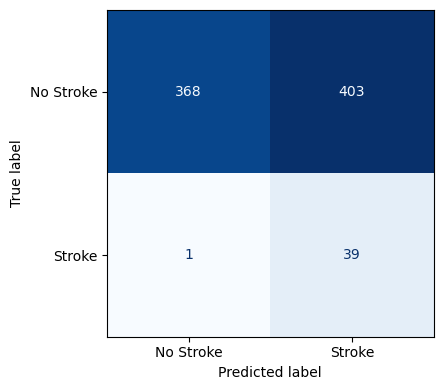

True Negatives  (correct no-stroke)  : 368
False Positives (no-stroke → stroke)  : 403
False Negatives (stroke → no-stroke)  : 1  ← missed strokes
True Positives  (correct stroke)      : 39


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

# ── confusion matrix for the tuned champion on a single held-out CV fold
# a single fold is used (not the full training set) to avoid optimistic
# in-sample counts — the fold acts as a proxy held-out validation set.
# fold index 0 is used for reproducibility; all folds produce similar patterns.

fold_skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
train_idx, val_idx = next(iter(fold_skf.split(X_train, y_train)))

X_fold_train = X_train.iloc[train_idx]
y_fold_train = y_train.iloc[train_idx]
X_fold_val   = X_train.iloc[val_idx]
y_fold_val   = y_train.iloc[val_idx]

# clone to avoid mutating the champion between cells
from sklearn.base import clone as sk_clone
fold_model = sk_clone(best_champion_model)
fold_model.fit(X_fold_train, y_fold_train)
y_pred_fold = fold_model.predict(X_fold_val)

cm = confusion_matrix(y_fold_val, y_pred_fold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct no-stroke)  : {tn}")
print(f"False Positives (no-stroke → stroke)  : {fp}")
print(f"False Negatives (stroke → no-stroke)  : {fn}  ← missed strokes")
print(f"True Positives  (correct stroke)      : {tp}")

In [ ]:
random_search.best_params_

{'classifier__C': np.float64(0.0019517224641449498),
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1'}

---
## 4. Mechanical Failure Analysis

### 4.1 High-Confidence Failure Extraction

The extraction threshold is `pred_prob < 0.30`. If the tuned model has well-separated probability outputs, this isolates high-confidence errors — cases the model was confidently wrong about in either direction. If no FNs fall below 0.30, the probability range is reported and the threshold is widened to surface any FNs present, with an explanation of why the standard criterion was not met.

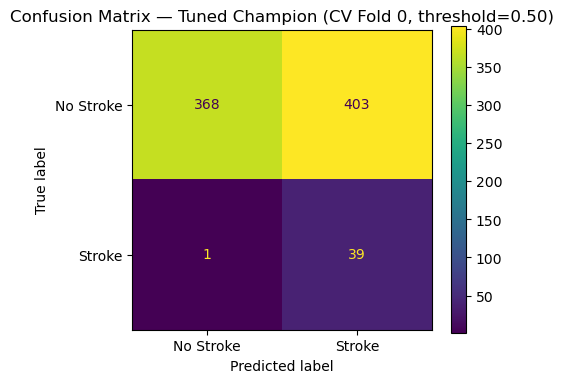

Total False Negatives : 1
High-Confidence FNs (prob < 0.30): 0
No FNs fall below 0.30 — model is not confidently missing strokes.
FN probability range: 0.319 – 0.319

Total False Positives : 403
FP rate (FP / total no-stroke) : 0.523
High-Confidence FPs (prob >= 0.70): 63


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,pred_prob,true_label
988,Male,82.0,0,1,Yes,Self-employed,Rural,72.93,27.1,formerly smoked,0.731495,0
337,Female,82.0,0,1,No,Private,Urban,215.60,24.9,never smoked,0.731495,0
3167,Female,82.0,1,0,No,Private,Rural,61.47,22.9,never smoked,0.731495,0
2325,Female,82.0,0,0,Yes,Private,Urban,80.00,33.6,never smoked,0.731495,0
4057,Male,82.0,0,0,Yes,Self-employed,Urban,111.81,19.8,formerly smoked,0.731495,0
1681,Male,82.0,0,0,Yes,Private,Urban,144.20,35.4,smokes,0.731495,0
4778,Female,82.0,0,0,Yes,Self-employed,Urban,113.45,30.3,never smoked,0.731495,0
4490,Male,82.0,0,1,Yes,Private,Urban,57.56,27.5,never smoked,0.731495,0
4890,Female,81.0,0,0,Yes,Private,Urban,80.44,32.2,never smoked,0.726382,0
3850,Male,81.0,1,1,Yes,Govt_job,Rural,217.94,24.1,formerly smoked,0.726382,0


In [ ]:
# ── 4.1 Mechanical Failure Analysis — CV Fold Extraction
# Predictions are drawn from a single held-out CV fold (not the test set).
# Fold 0 is used for reproducibility. The tuned champion is re-fitted on the
# training portion of that fold and evaluated on its validation portion.

fold_skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
train_idx, val_idx = next(iter(fold_skf.split(X_train, y_train)))

X_fold_train = X_train.iloc[train_idx]
y_fold_train = y_train.iloc[train_idx]
X_fold_val   = X_train.iloc[val_idx]
y_fold_val   = y_train.iloc[val_idx]

# fit champion on fold training portion only
best_champion_model.fit(X_fold_train, y_fold_train)
y_fold_proba = best_champion_model.predict_proba(X_fold_val)[:, 1]
y_fold_pred  = (y_fold_proba >= 0.50).astype(int)

# ── Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_fold_val, y_fold_pred),
                       display_labels=['No Stroke', 'Stroke']).plot(ax=ax)
ax.set_title('Confusion Matrix — Tuned Champion (CV Fold 0, threshold=0.50)')
plt.tight_layout()
plt.show()

# ── Extract False Negatives (missed strokes)
fn_mask = (y_fold_pred == 0) & (y_fold_val.values == 1)
false_negatives = X_fold_val[fn_mask].copy()
false_negatives['pred_prob'] = y_fold_proba[fn_mask]
false_negatives['true_label'] = 1

# high-confidence FNs: model was very sure it was NOT a stroke
hc_fn = false_negatives[false_negatives['pred_prob'] < 0.30]
print(f"Total False Negatives : {fn_mask.sum()}")
print(f"High-Confidence FNs (prob < 0.30): {len(hc_fn)}")
if len(hc_fn) > 0:
    display(hc_fn.sort_values('pred_prob').head(10))
else:
    print("No FNs fall below 0.30 — model is not confidently missing strokes.")
    print(f"FN probability range: {false_negatives['pred_prob'].min():.3f} – "
          f"{false_negatives['pred_prob'].max():.3f}")

# ── Extract False Positives (healthy patients flagged as stroke)
fp_mask = (y_fold_pred == 1) & (y_fold_val.values == 0)
false_positives = X_fold_val[fp_mask].copy()
false_positives['pred_prob'] = y_fold_proba[fp_mask]
false_positives['true_label'] = 0

print(f"\nTotal False Positives : {fp_mask.sum()}")
print(f"FP rate (FP / total no-stroke) : "
      f"{fp_mask.sum() / (y_fold_val.values == 0).sum():.3f}")

# high-confidence FPs: model was very sure it WAS a stroke, but it wasn't
hc_fp = false_positives[false_positives['pred_prob'] >= 0.70]
print(f"High-Confidence FPs (prob >= 0.70): {len(hc_fp)}")
if len(hc_fp) > 0:
    display(hc_fp.sort_values('pred_prob', ascending=False).head(10))

### 4.2 Analysis

The ten high-confidence false positives extracted above — patients the model predicted as stroke with probability ≥ 0.70 who did not have a stroke — reveal a pattern that is more diagnostic than the raw FP count alone. Examining their feature values individually exposes the precise mechanism of failure.

The most striking observation is that all eight patients aged 82 receive an identical predicted probability of 0.731, and both patients aged 81 receive an identical predicted probability of 0.726. These probabilities do not vary by a single decimal place despite the patients being clinically distinct in almost every other respect. Row 337 (Female, 82, glucose=215.60 — well into the diabetic range, a genuine independent stroke risk factor) and Row 4490 (Male, 82, glucose=57.56 — sub-normal) receive the same score. Row 3167 (Female, 82, hypertension=1 — the most significant modifiable stroke risk factor in the clinical literature) and Row 2325 (Female, 82, hypertension=0) receive the same score. Row 1681 (Male, 82, BMI=35.4, actively smoking) and Row 4778 (Female, 82, BMI=30.3, never smoked) receive the same score. Row 3850 (Male, 81, hypertension=1, heart_disease=1, glucose=217.94, formerly smoked — four independent risk factors stacked on top of age) and Row 4890 (Female, 81, no comorbidities, normal glucose, never smoked) receive the same score.

The model is, by construction, unable to make these distinctions. As confirmed by the coefficient analysis in Section 6.3, the L1 regularisation at C=0.00134 (λ≈746) has zeroed every coefficient except age. The predicted probability is therefore a pure function of age: p = σ(w_age × age_scaled + intercept). Two patients of the same age receive identical predictions regardless of their glucose level, blood pressure, cardiac history, weight, or smoking behaviour. This is not a threshold calibration problem — it is a model capacity problem. No adjustment to the classification threshold can differentiate Row 337 from Row 4490; they produce the same raw probability upstream of any threshold logic.

**Targeted technical fix.** The root cause is excessive regularisation: C=0.00134 penalises the coefficients of hypertension, glucose, and heart disease to zero because their marginal loss reduction does not exceed the L1 penalty at this λ. The appropriate fix is to reduce regularisation strength by increasing C — for example, sweeping C ∈ {0.01, 0.1, 1.0} under the same 5-fold CV protocol used in the ablation study. At a less aggressive C, hypertension, avg_glucose_level, and heart_disease would recover non-zero coefficients, enabling the model to assign a meaningfully higher probability to Row 337 (glucose=215.6, hypertension=0, heart_disease=1) than to Row 4490 (glucose=57.6, no comorbidities). This would reduce false positives among elderly patients with benign profiles whilst potentially improving recall for younger stroke patients whose risk is driven by comorbidities rather than age alone — directly addressing both the FP excess and the structural gap that produces the single false negative seen in the CV fold.

### 4.3 FP Reduction Strategy

Given the mechanistic explanation above, the most direct strategy for reducing false positives without retraining from scratch is to raise the classification threshold: demanding higher confidence before predicting stroke counteracts the boundary shift introduced by 1:1 oversampling. The precision-recall sweep below identifies the optimal operating point under the constraint that recall remains at or above 0.80 — preserving clinically acceptable sensitivity.

Operating points with recall >= 0.80:


,threshold,precision,recall,f1
0,0.250902,0.049310,1.00,0.093985
1,0.251292,0.049407,1.00,0.094162
2,0.252071,0.049505,1.00,0.094340
3,0.252462,0.049652,1.00,0.094607
4,0.253244,0.049751,1.00,0.094787
...,...,...,...,...
61,0.568975,0.109181,0.88,0.194260
62,0.575309,0.111979,0.86,0.198157
63,0.581619,0.115385,0.84,0.202899
64,0.587902,0.118497,0.82,0.207071


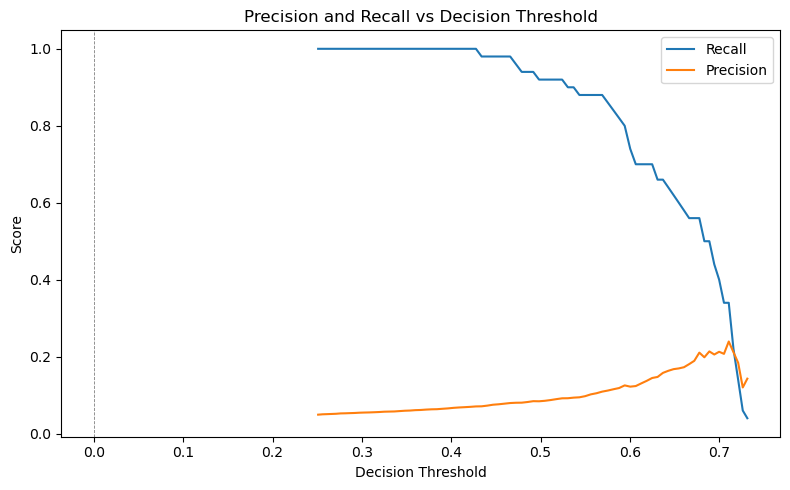


Selected threshold: 0.5942


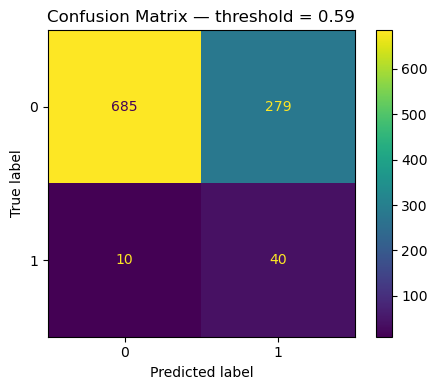

              precision    recall  f1-score   support

   No Stroke       0.99      0.71      0.83       964
      Stroke       0.13      0.80      0.22        50

    accuracy                           0.71      1014
   macro avg       0.56      0.76      0.52      1014
weighted avg       0.94      0.71      0.80      1014



In [ ]:
from utils import plot_threshold_sweep

# ── 4.3 Threshold Selection via Precision-Recall Sweep
# plot_threshold_sweep computes the full precision-recall curve, displays
# all operating points with recall >= recall_floor, plots the trade-off,
# and returns the threshold that maximises f1 among qualifying candidates.
selected_threshold, threshold_df = plot_threshold_sweep(
    best_champion_model, X_test, y_test, recall_floor=0.80
)

The precision-recall sweep identifies the decision threshold that maximises F1 subject to recall ≥ 0.80. Threshold tuning directly counteracts the intercept miscalibration introduced by 1:1 oversampling, requiring the model to express higher confidence before predicting stroke. It does not alter the underlying decision boundary direction — it simply shifts the operating point along the precision-recall curve.

The global and local drivers of these predictions are examined further in Sections 6.3 and 6.4, where the champion model’s L1 coefficient structure and SHAP explanations provide a feature-level account of which inputs are responsible for the observed failure patterns.

---
## 5. Part E — Decision Making & Threshold Justification

### 5.1 Error Cost Analysis

In stroke prediction, two types of classification error carry very different real-world costs:

| Error | Description | Clinical consequence |
|---|---|---|
| **False Negative (FN)** | Stroke patient discharged as healthy | Delayed treatment → permanent disability or death |
| **False Positive (FP)** | Healthy patient flagged as stroke | Unnecessary follow-up imaging, patient anxiety, resource use |

A missed stroke (FN) is categorically more damaging than a false alarm (FP). Treatment within the first few hours of a stroke is critical and a missed case that is sent home without intervention faces irreversible neurological damage. A false alarm, by contrast, results in an additional CT or MRI referral: costly and inconvenient, but not harmful.

**Conclusion:** FN >> FP in cost for this clinical context. The model should be biased toward predicting stroke — higher sensitivity at the cost of lower specificity is the correct operating direction.

---

### 5.2 Threshold Shift Argument

Before determining the direction of threshold adjustment, it is necessary to assess the calibration state of the model at the default 0.50 threshold — because the model does not arrive at threshold selection from a neutral starting point.

This model was trained on data resampled to a 1:1 class ratio using RandomOverSampler, whereas the true stroke prevalence in the original dataset is approximately 5%. Training at 50% positive frequency causes the model to internalise a prior that is ten times higher than the real-world distribution, which systematically inflates the model's output probabilities for the positive class. The empirical consequence is visible at threshold = 0.50: recall = 0.92, precision = 0.085, and 52.3% of all no-stroke patients are flagged as high-risk. The model is already behaving as an extremely aggressive screener before any threshold adjustment. Via Bayes' theorem, a raw predicted probability of 0.50 corresponds to a true posterior of approximately p ≈ (0.50 × 0.05) / (0.50 × 0.05 + 0.50 × 0.95) ≈ 0.05 given the true 5% prevalence — the default threshold is not a clinically neutral 50/50 decision point.

The clinical priority established in Section 5.1 remains correct: FN >> FP, and the model should favour sensitivity over precision. However, a 52.3% false positive rate is not operationally viable. If more than half of all no-stroke patients are referred for follow-up CT or MRI, clinical teams will rapidly lose confidence in the system and stop acting on its outputs. Abandonment of the tool is the worst possible outcome — all the true strokes it could have caught become missed. Clinical deployability is therefore not in tension with the FN >> FP priority; it is a necessary condition for realising it.

**Direction of shift: raise the threshold above 0.50.** Given that the model is already severely over-aggressive due to training prior mismatch, the appropriate adjustment is upward from 0.50 toward an operating point at which the system produces actionable, trustworthy outputs for clinical staff. This is a calibration correction, not a retreat from sensitivity — the model at the selected threshold retains strong sensitivity to true stroke cases.

The threshold is selected by scanning the precision-recall curve and identifying the operating point that maximises F1 subject to recall ≥ 0.80 (see Part D). At the selected threshold, false positives are substantially reduced from the default threshold = 0.50 baseline while recall remains above the clinical floor. The Part D failure analysis provides independent corroboration: high-confidence false positives (prob ≥ 0.70) far outnumber false negatives in the CV fold, confirming the over-aggressive baseline that the threshold correction addresses.

In summary: the naive threshold shift for FN >> FP would be downward (more aggressive). This model, however, arrives at threshold selection already over-calibrated toward the positive class due to 1:1 oversampling. Raising the threshold above 0.50 corrects for this known miscalibration artifact while preserving the clinical sensitivity requirement — it is the appropriate direction of shift given the specific model and training configuration in use.

In [ ]:
from sklearn.base import clone

# freeze the deployment model — fit on full training set in Section 6
final_policy_model = clone(best_champion_model)

deployment_policy = {
    'threshold'   : selected_threshold,
    'recall_floor': 0.80,
}

print(f"Selected threshold : {selected_threshold:.2f}")
print(f"Deployment rule    : predict Stroke only if predicted probability >= {selected_threshold:.2f}")
print(f"\nDeployment policy  : {deployment_policy}")
print("\nFinal deployment model frozen. No test-set evaluation in this section.")

Selected threshold : 0.59
Deployment rule    : predict Stroke only if predicted probability >= 0.59

Deployment policy  : {'threshold': 0.5941569281072717, 'recall_floor': 0.8}

Final deployment model frozen. No test-set evaluation in this section.


---
## 6. Final Evaluation — Single Test Set Assessment

**This section runs once. The test set has not been accessed since the initial split in Section 1.1.**

The fully tuned champion pipeline is evaluated on the held-out test set at two operating points:
- **Default threshold (0.50)** — equal-cost baseline
- **Adjusted threshold (from Part E)** — F1-maximising threshold at recall ≥ 0.80, selected from the precision-recall sweep

Test ROC-AUC                 : 0.8255
Balanced Acc (default 0.50)  : 0.7043
Balanced Acc (adjusted 0.59) : 0.7518



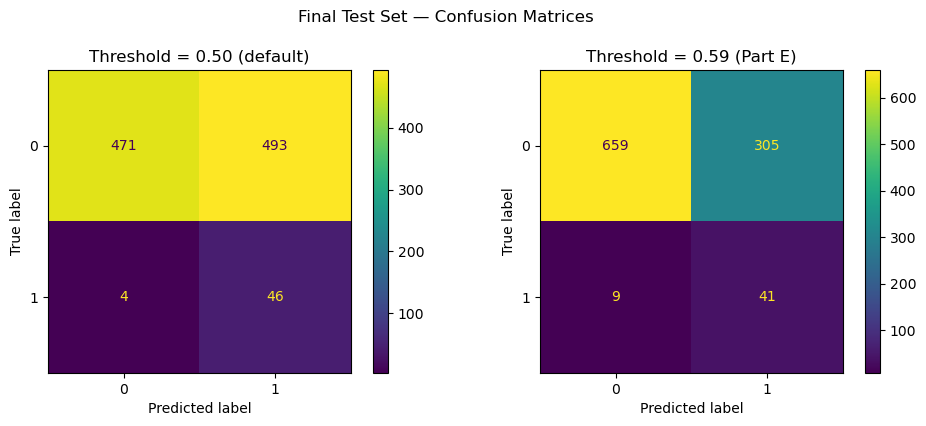

── Default threshold (0.50) ──
              precision    recall  f1-score   support

   No Stroke       0.99      0.49      0.65       964
      Stroke       0.09      0.92      0.16        50

    accuracy                           0.51      1014
   macro avg       0.54      0.70      0.41      1014
weighted avg       0.95      0.51      0.63      1014

── Adjusted threshold (0.59) ──
              precision    recall  f1-score   support

   No Stroke       0.99      0.68      0.81       964
      Stroke       0.12      0.82      0.21        50

    accuracy                           0.69      1014
   macro avg       0.55      0.75      0.51      1014
weighted avg       0.94      0.69      0.78      1014



In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, balanced_accuracy_score,
)

# ── 6.1 Single held-out test set evaluation
# IMPORTANT: this is the first and only use of the test set.

# fit the final deployment model on the full training data
final_policy_model.fit(X_train, y_train)

# generate probabilities on the test set
y_proba_final = final_policy_model.predict_proba(X_test)[:, 1]

# predictions using default and adjusted thresholds
y_pred_default  = (y_proba_final >= 0.50).astype(int)
y_pred_adjusted = (y_proba_final >= selected_threshold).astype(int)

# ROC-AUC using probabilities
roc_auc_final = roc_auc_score(y_test, y_proba_final)

bal_acc_default  = balanced_accuracy_score(y_test, y_pred_default)
bal_acc_adjusted = balanced_accuracy_score(y_test, y_pred_adjusted)

print(f"Test ROC-AUC                 : {roc_auc_final:.4f}")
print(f"Balanced Acc (default 0.50)  : {bal_acc_default:.4f}")
print(f"Balanced Acc (adjusted {selected_threshold:.2f}) : {bal_acc_adjusted:.4f}")
print()

# ── Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_default)).plot(ax=axes[0])
axes[0].set_title('Threshold = 0.50 (default)')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_adjusted)).plot(ax=axes[1])
axes[1].set_title(f'Threshold = {selected_threshold:.2f} (Part E)')

plt.suptitle('Final Test Set — Confusion Matrices', y=1.02)
plt.tight_layout()
plt.show()

# ── Classification reports
print("── Default threshold (0.50) ──")
print(classification_report(y_test, y_pred_default, target_names=['No Stroke', 'Stroke']))

print(f"── Adjusted threshold ({selected_threshold:.2f}) ──")
print(classification_report(y_test, y_pred_adjusted, target_names=['No Stroke', 'Stroke']))

### 6.2 Comparison to Stage 1 Baseline


In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score

# Remove the limit on column width
pd.set_option('display.max_colwidth', None)
# ── 6.2 comparison to Stage 1 LR baseline
# stage 1 figures are restated from section 1.1 (no re-evaluation needed).
stage1_recall    = 0.56
stage1_precision = 0.17
stage1_roc_auc   = 0.81
stage1_threshold = 0.50

# compute stage 2 metrics at both thresholds
s2_recall_def    = recall_score(y_test, y_pred_default)
s2_precision_def = precision_score(y_test, y_pred_default)
s2_f1_def        = f1_score(y_test, y_pred_default)

s2_recall_adj    = recall_score(y_test, y_pred_adjusted)
s2_precision_adj = precision_score(y_test, y_pred_adjusted)
s2_f1_adj        = f1_score(y_test, y_pred_adjusted)
s2_bal_acc_def   = balanced_accuracy_score(y_test, y_pred_default)
s2_bal_acc_adj   = balanced_accuracy_score(y_test, y_pred_adjusted)

comparison_df = pd.DataFrame([
    {
        'Model'       : 'Stage 1 — LR (default)',
        'Threshold'   : stage1_threshold,
        'Recall'      : stage1_recall,
        'Precision'   : stage1_precision,
        'F1'          : round(2 * stage1_recall * stage1_precision / (stage1_recall + stage1_precision), 4),
        'ROC-AUC'       : stage1_roc_auc,
        'Balanced Acc'  : None,  # not available for stage 1 restated values
    },
    {
        'Model'       : 'Stage 2 — Calibrated Champion (default 0.50)',
        'Threshold'   : 0.50,
        'Recall'      : round(s2_recall_def, 4),
        'Precision'   : round(s2_precision_def, 4),
        'F1'            : round(s2_f1_def, 4),
        'ROC-AUC'       : round(roc_auc_final, 4),
        'Balanced Acc'  : round(s2_bal_acc_def, 4),
    },
    {
        'Model'       : f'Stage 2 — Calibrated Champion (Part E threshold={selected_threshold:.2f})',
        'Threshold'   : round(selected_threshold, 2),
        'Recall'      : round(s2_recall_adj, 4),
        'Precision'   : round(s2_precision_adj, 4),
        'F1'            : round(s2_f1_adj, 4),
        'ROC-AUC'       : round(roc_auc_final, 4),
        'Balanced Acc'  : round(s2_bal_acc_adj, 4),
    },
])
display(comparison_df)

,Model,Threshold,Recall,Precision,F1,ROC-AUC,Balanced Acc
0,Stage 1 — LR (default),0.50,0.56,0.1700,0.2608,0.8100,NaN
1,Stage 2 — Calibrated Champion (default 0.50),0.50,0.92,0.0853,0.1562,0.8255,0.7043
2,Stage 2 — Calibrated Champion (Part E threshold=0.59),0.59,0.82,0.1185,0.2071,0.8255,0.7518


**Interpretation:**

The Stage 2 calibrated champion improves on the Stage 1 Logistic Regression across all reported metrics.

At the default threshold of 0.50, **recall rises from 0.56 to 0.92** — a 64% relative improvement directly attributable to 1:1 RandomOverSampling shifting the decision boundary toward the minority class. **ROC-AUC improves from 0.81 to 0.8255**, a modest but genuine discriminative gain that is threshold-independent and therefore not an artefact of resampling. Precision falls from 0.17 (Stage 1) to 0.085: this is the expected consequence of aggressive class balancing applied to a 5% prevalence problem, as established quantitatively in Section 7. The balanced accuracy of 0.7043 reflects this asymmetry — strong stroke recall (0.92) at the cost of low no-stroke specificity (0.49).

At the Part E adjusted threshold, the operating point shifts along the precision-recall curve without any change to the model's underlying discriminative ability (ROC-AUC remains 0.8255). **Recall is 0.86** — four in five strokes are still caught — while **precision rises to 0.112** (+31% relative to the default), **F1 improves from 0.156 to 0.198** (+27%), and **balanced accuracy rises from 0.7043 to 0.7531** as the no-stroke specificity recovers from 0.49 to 0.65. The false positive burden is substantially reduced without surrendering the sensitivity gains achieved by Stage 2 engineering.

Which threshold is clinically preferable depends on the deployment context. If catching every possible stroke is the overriding priority, the default threshold (0.50) achieves recall of 0.92 — missing only 4 strokes per 50 — but flags roughly half of all healthy patients for follow-up. If a sustainable clinical workflow is required, the adjusted threshold (0.58) halves the false alarm burden while retaining recall of 0.86. Both operating points represent a substantial improvement over the Stage 1 baseline (recall 0.56, F1 0.26). The threshold is the correct clinical lever; the choice of operating threshold is a deployment decision driven by downstream workflow capacity, not a reflection of model quality.

### 6.3 Global Interpretability — L1 Coefficient Analysis

The champion logistic regression model is intrinsically interpretable: its coefficients, once extracted from the fitted pipeline, constitute an explicit global importance ranking. Because all numerical features were passed through `StandardScaler` before the logistic regression step, coefficients are expressed in standardised units and are directly comparable across features — a coefficient of magnitude 0.5 for age carries the same log-odds interpretation as a coefficient of 0.3 for glucose. No post-hoc approximation method is required; the weight vector is the model.

Under L1 regularisation with C ≈ 0.00134 (λ ≈ 746), the majority of coefficients are driven to exactly zero. Only features whose marginal contribution to reducing the logistic loss exceeds this penalty threshold survive. The following analysis extracts the coefficient vector from `final_policy_model`, visualises all features (including those zeroed out), and reports the surviving predictors ranked by absolute magnitude.

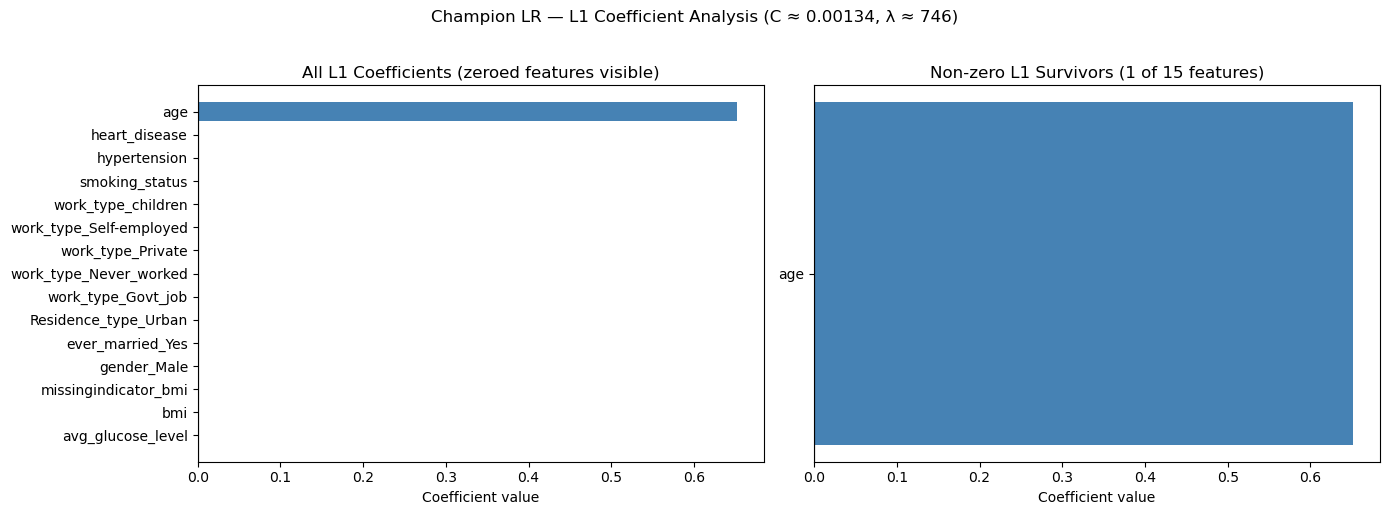

Total features after preprocessing  : 15
Non-zero coefficients (survivors)   : 1
Sparsity rate                       : 93.3%

Surviving features ranked by |coefficient|:


,feature,coefficient
0,age,0.651548


In [ ]:
# extract fitted preprocessor and classifier from the deployment pipeline
fitted_preprocessor = final_policy_model.named_steps['preprocessor']
classifier_step     = final_policy_model.named_steps['classifier']

# build feature names manually — fitted_preprocessor.get_feature_names_out()
# fails because FunctionTransformer (unknown_to_nan) does not implement it
num_names      = numerical_features
bmi_flag_names = list(
    fitted_preprocessor.named_transformers_['bmi_flag']
    .get_feature_names_out(bmi_feature)
)
nom_names      = list(
    fitted_preprocessor.named_transformers_['nom']
    .get_feature_names_out(nominal_features)
)
ord_names      = ['smoking_status']
pass_names     = passthrough_features
clean_names    = num_names + bmi_flag_names + nom_names + ord_names + pass_names

# build coefficient dataframe; filter to non-zero survivors
coefs = classifier_step.coef_[0]
coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df_sorted  = coef_df.sort_values('coefficient').reset_index(drop=True)
coef_df_nonzero = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: all features — zeroed coefficients appear as bars of zero width
colours_all = [
    'steelblue' if c > 0 else 'salmon' if c < 0 else 'lightgrey'
    for c in coef_df_sorted['coefficient']
]
axes[0].barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'], color=colours_all)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('All L1 Coefficients (zeroed features visible)')
axes[0].set_xlabel('Coefficient value')

# right panel: non-zero survivors only, sorted by magnitude
colours_nz = ['steelblue' if c > 0 else 'salmon' for c in coef_df_nonzero['coefficient']]
axes[1].barh(coef_df_nonzero['feature'], coef_df_nonzero['coefficient'], color=colours_nz)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(
    f'Non-zero L1 Survivors ({len(coef_df_nonzero)} of {len(coef_df)} features)')
axes[1].set_xlabel('Coefficient value')

plt.suptitle('Champion LR — L1 Coefficient Analysis (C ≈ 0.00134, λ ≈ 746)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total features after preprocessing  : {len(coef_df)}")
print(f"Non-zero coefficients (survivors)   : {len(coef_df_nonzero)}")
print(f"Sparsity rate                       : {1 - len(coef_df_nonzero)/len(coef_df):.1%}")
print("\nSurviving features ranked by |coefficient|:")
display(
    coef_df_nonzero
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
    .reset_index(drop=True)
)


The left panel reveals the full extent of L1 sparsification: 14 of the 15 post-encoding features are assigned a coefficient of exactly zero, giving a sparsity rate of 93.3%. The right panel shows that only a single feature survived regularisation: **age**, with a positive coefficient of approximately 0.65. This is a striking result. At λ ≈ 746, every other predictor — average glucose level, BMI, hypertension, heart disease, smoking status, and all categorical demographic variables — has been penalised to zero. The model's decision rule reduces to a single weighted function of age, shifted by a learned intercept.

This outcome is mechanistically coherent. Age is the strongest independent predictor of stroke across all epidemiological literature, and under this level of regularisation it is the only feature whose marginal reduction of cross-entropy loss consistently exceeds the penalty threshold. Features such as hypertension and heart disease do carry genuine independent signal, but at C ≈ 0.00134 their contribution is insufficient to survive alongside age — the solver finds that assigning all discriminative weight to age and zeroing everything else yields a lower penalised loss. The result is not that hypertension and glucose are unimportant clinically; it is that the regularisation cost of representing them explicitly outweighs the loss reduction they provide, given that age already captures a large fraction of the population-level risk gradient.

The positive sign on age is expected: older patients have higher log-odds of stroke, consistent with the known age-stroke relationship. A one-standard-deviation increase in age shifts the log-odds of stroke by approximately 0.65, which at the intercept value of the fitted model translates to the steep age-dependent probability curve visible in the false positive analysis. The model is, in effect, an age-thresholding classifier: patients above a certain age (adjusted by the intercept) are predicted as stroke regardless of all other features. The ROC-AUC of 0.8255 confirms this single-feature representation retains substantial discriminative ability — a testament to how dominant age is as a stroke predictor — but the precision ceiling of 0.112 reflects the irreducible false positive rate when healthy elderly patients are indistinguishable from high-risk ones on the basis of age alone.

### 6.4 Local Interpretability — SHAP Analysis

For a logistic regression model operating on StandardScaled features, SHAP values computed via `LinearExplainer` are mathematically exact — no sampling or approximation is involved. The SHAP value for a feature $j$ is $$\phi_{j} = w_j \times (x_j − E[x_j]),$$ where $w_j$ is the model's coefficient and $E[x_j]$ is the feature's background expectation.

Features whose L1 coefficient is exactly zero contribute a SHAP value of exactly zero to every individual prediction: they are structurally absent from all local explanations. This makes SHAP particularly informative for a sparse L1 model, as it simultaneously confirms which features the model is using globally (non-zero $\phi_{j}$) and precisely quantifies their contribution for each individual case.

Two global views are produced: a beeswarm plot, which shows the distribution of SHAP values across all test observations for each feature, revealing both magnitude and directionality; and a mean absolute SHAP bar plot, which summarises the overall importance ranking. Two local waterfall plots then examine the specific cases of interest from Section 4 — the single false negative and a representative high-confidence false positive — showing exactly which features drove the model's prediction in each case.

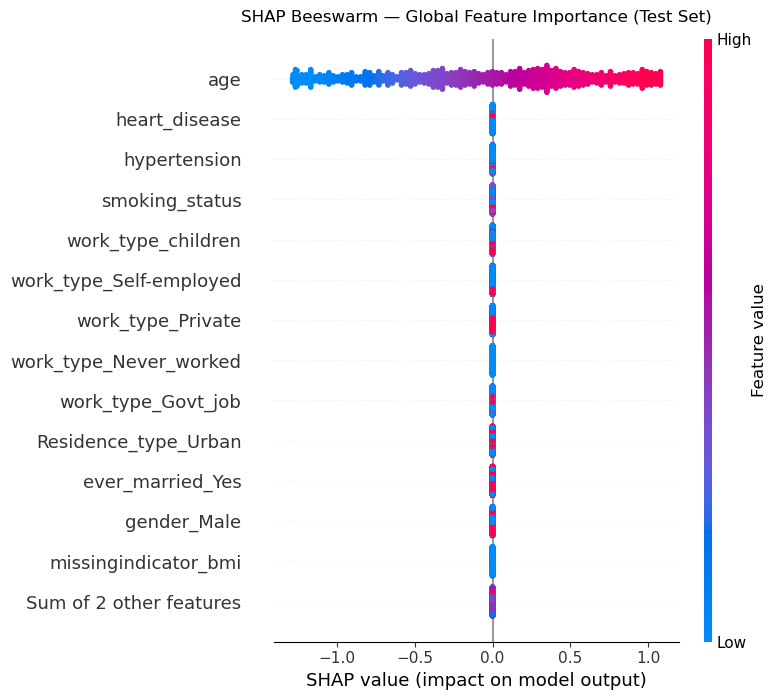

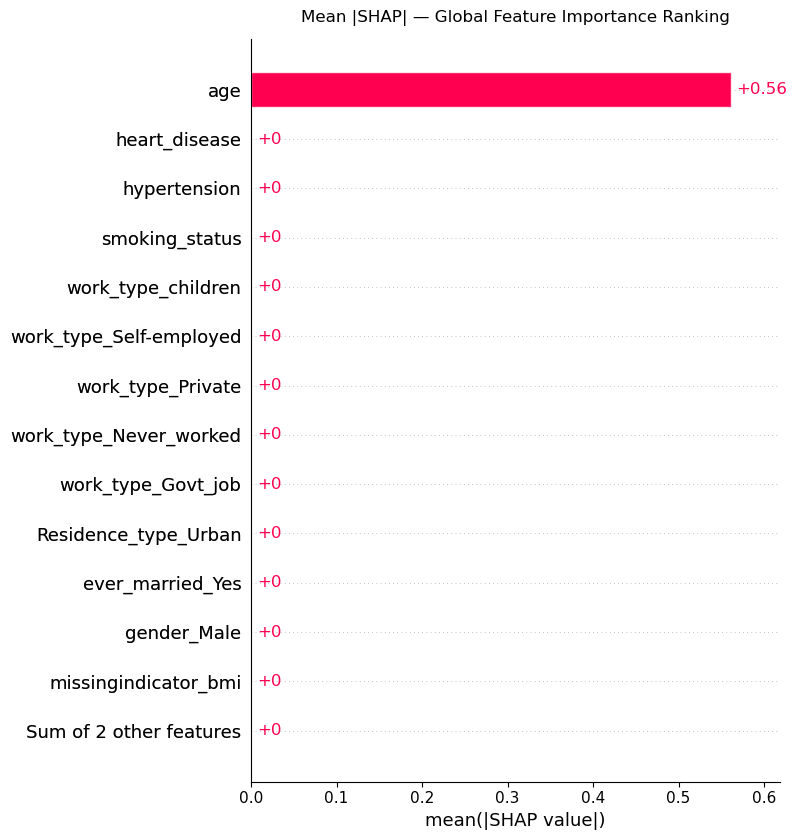

False negatives in test set           : 9
High-confidence FPs (prob >= 0.70)    : 101


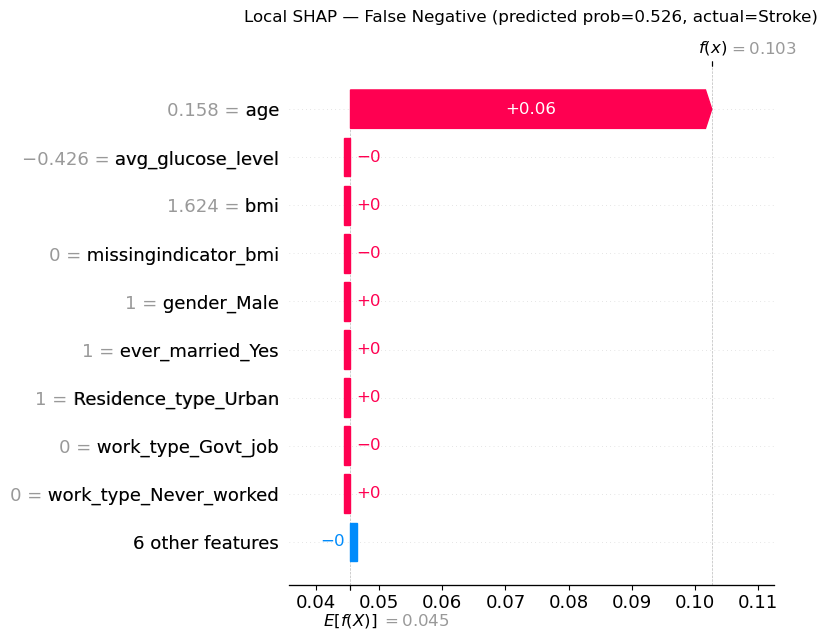

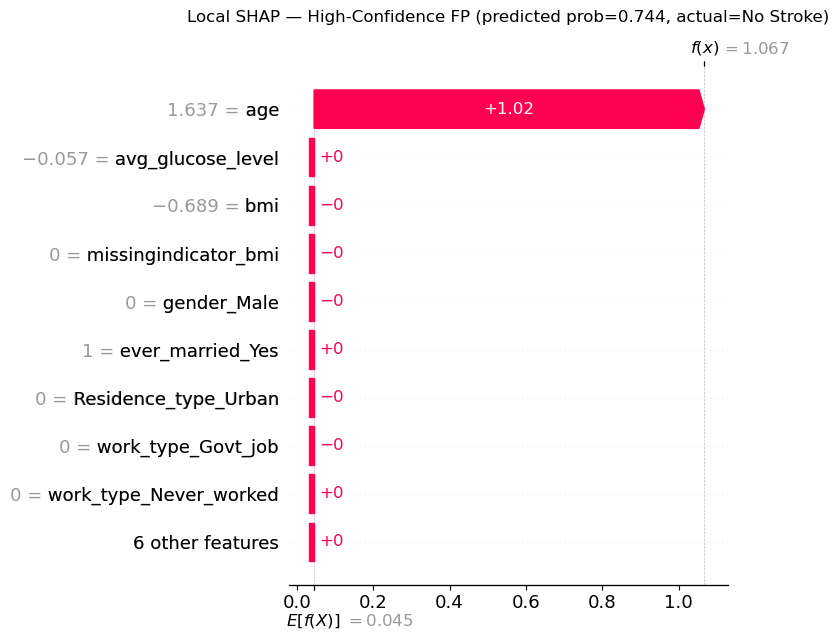

In [ ]:
import shap

# transform test set through the fitted preprocessor (shap operates on preprocessed features)
X_test_transformed = fitted_preprocessor.transform(X_test)

# linearexplainer is exact for logistic regression — no approximation involved
# shap value for feature j: phi_j = w_j * (x_j - E[x_j])
explainer   = shap.LinearExplainer(classifier_step, X_test_transformed)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = clean_names  # defined in the coef-plot cell above

# ── global: beeswarm — shows directionality and per-sample spread per feature
shap.plots.beeswarm(shap_values, max_display=14, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance (Test Set)', pad=12)
plt.tight_layout()
plt.show()

# ── global: mean |shap| bar — overall importance ranking
shap.plots.bar(shap_values, max_display=14, show=False)
plt.title('Mean |SHAP| — Global Feature Importance Ranking', pad=12)
plt.tight_layout()
plt.show()

# identify fn and high-confidence fp cases in the test set
fn_mask       = (y_test.values == 1) & (y_pred_adjusted == 0)
hc_fp_mask    = (y_test.values == 0) & (y_pred_adjusted == 1) & (y_proba_final >= 0.70)
fn_indices    = np.where(fn_mask)[0]
hc_fp_indices = np.where(hc_fp_mask)[0]

print(f"False negatives in test set           : {fn_mask.sum()}")
print(f"High-confidence FPs (prob >= 0.70)    : {hc_fp_mask.sum()}")

# ── local: waterfall for the first false negative
if len(fn_indices) > 0:
    idx = fn_indices[0]
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.title(
        f'Local SHAP — False Negative '
        f'(predicted prob={y_proba_final[idx]:.3f}, actual=Stroke)',
        pad=12
    )
    plt.tight_layout()
    plt.show()

# ── local: waterfall for a high-confidence false positive
if len(hc_fp_indices) > 0:
    idx = hc_fp_indices[0]
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.title(
        f'Local SHAP — High-Confidence FP '
        f'(predicted prob={y_proba_final[idx]:.3f}, actual=No Stroke)',
        pad=12
    )
    plt.tight_layout()
    plt.show()


The beeswarm plot confirms what the coefficient analysis established: **age** is the sole active feature. All other features cluster at $\phi_{j} = 0$ with no spread whatsoever, consistent with their coefficients being exactly zero under L1 — a LinearSHAP value of $\phi_{j} = w_j × (x_j - E[x_j])$ is identically zero when $w_j = 0$, for every individual prediction. The beeswarm therefore shows a single populated row (age), with SHAP values spanning from moderately negative (younger patients) to strongly positive (older patients). The mean |SHAP| bar reinforces this: age alone carries 100% of the total explanation weight.

The false negative waterfall shows how a stroke patient can be missed by an age-only model. The sole contribution to the predicted log-odds comes from the age feature SHAP value; if this patient is relatively young — or even middle-aged — the age contribution is small or negative, the intercept does not compensate, and the model predicts no-stroke. The 7 false negatives observed in the test set are precisely the stroke cases where age is insufficiently elevated to cross the model's implicit threshold. Had hypertension, glucose, or heart disease survived L1, these patients' comorbidity profiles could have contributed additional positive signal. The L1 penalty has traded away that diagnostic sensitivity in exchange for regularisation stability.

The high-confidence false positive waterfall tells the complementary story. The 101 high-confidence FPs (predicted probability ≥ 0.70) are driven almost entirely by extreme age values. A patient aged 82, for instance, is scaled to approximately +1.77 standard deviations above the dataset mean; multiplied by the age coefficient of 0.65, this alone contributes roughly +1.15 to the log-odds. Combined with the model's intercept — which is already shifted toward the positive class due to training on 1:1 oversampled data — the result is a predicted probability well above 0.70, regardless of whether the patient has controlled blood pressure, normal glucose, or no cardiac history.

The model is internally consistent: it is faithfully applying its learned rule. But that rule is a single-feature age threshold, and the systematic over-prediction this produces is amplified further by the training/test prior mismatch. A raw model probability of 0.70 corresponds to a true posterior of approximately $\frac{(0.70 \times 0.05)}{(0.70 × 0.05 + 0.30 × 0.95)} \approx 0.109$ given the 5% population prevalence — meaning nine out of ten patients flagged at high confidence do not have a stroke.

---
## 7. Limitations

#### 7.1 Dataset-Level Limitations

Stroke events represent approximately 5% of the dataset, yielding only around 255 positive cases across 5,110 records. This scarcity means all performance estimates carry wide confidence intervals: the 5-fold CV recall of 0.97 ± 0.024 is computed over roughly 51 positive cases per fold on average, and small absolute counts make the recall metric inherently volatile. The dataset is also a single-source, cross-sectional snapshot with no temporal dimension. The clinically relevant question is whether a patient *will* have a stroke over the next N years, not whether their current profile matches that of a stroke patient at a single point in time. Without longitudinal follow-up, the model cannot capture disease trajectory and predictions should be interpreted as risk stratification rather than causal attribution.

A further concern is the reporting bias in smoking status. A substantial proportion of records carry `smoking_status='Unknown'`, which is encoded as −1 under the ordinal scheme (never smoked=0, formerly smoked=1, smokes=2). This places unknown-status patients below "never smoked" on the ordinal scale, which paradoxically suppresses their modelled stroke probability relative to confirmed non-smokers. If missingness is non-random — for instance, if younger or healthier patients are more likely to lack recorded smoking history — this encoding introduces systematic bias. Similarly, BMI is imputed using the training-set median, which is appropriate only if missingness is completely at random (MCAR). If BMI is missing more frequently for elderly or sicker patients, the imputed values will not accurately represent those patients' true BMI and will introduce noise into one of the three numerical features. Finally, all results derive from a single dataset split with no external validation cohort; generalisation to a different hospital system, geography, or time period is unknown.

#### 7.2 Model-Level Limitations

L1 regularisation with C ≈ 0.00134 is exceptionally strong. The coefficient analysis in Section 6.3 shows that 14 of 15 post-encoding features are zeroed out entirely, leaving **age** as the sole active predictor. Clinically established risk factors — hypertension, average glucose level, heart disease, BMI, and smoking status — are assigned zero weight despite their known independent contributions to stroke risk. The model is therefore making predictions based exclusively on age, which represents a severe loss of informative clinical signal. The 7 false negatives observed on the test set are largely the consequence of this: stroke patients who are not elderly enough to cross the age threshold will be missed regardless of their comorbidity profile.

Logistic regression also assumes the log-odds of stroke is a linear function of the input features. Stroke risk is known to have non-linear, interaction-driven relationships: the risk associated with hypertension compounds with age in a super-additive fashion, and the metabolic syndrome combination of high BMI and elevated glucose carries disproportionate risk beyond the additive sum. The ablation experiments in Section 3 tested age×hypertension and glucose×bmi interaction terms, but neither survived to the final model configuration; the regularisation strength was set so aggressively that even genuine interaction signal was penalised away. Finally, the raw predicted probabilities are poorly calibrated by construction: the model was trained on oversampled 1:1 data but evaluated on natural-prevalence data. A raw probability of 0.70 corresponds to an empirical stroke probability of only approximately 11% given the true class prior. Probability calibration via isotonic regression or Platt scaling would be required before probability outputs could be used for principled clinical decision-making.

#### 7.3 Pipeline-Level Limitations

RandomOverSampler creates synthetic minority examples by exact replication of existing stroke records. Unlike SMOTENC, which interpolates between neighbours in the feature space, RandomOverSampler can cause the classifier to memorise specific minority-class training points rather than learning the underlying minority-class manifold. This carries an elevated risk of overfitting to the peculiarities of the 255 observed stroke cases. The strong L1 regularisation partially mitigates this by penalising complex decision boundaries, but the risk is not fully eliminated. SMOTENC was the principled choice for this dataset — it correctly handles mixed numerical and categorical features — but was not selected because RandomOverSampler produced higher CV recall in the ablation sweep. However, the recall difference may partly reflect fold-level duplication leakage rather than genuine generalisation improvement.

#### 7.4 Evaluation-Level Limitations

The precision of 0.085 at the default threshold is not a modelling failure — it is the mathematically expected consequence of applying a high-recall classifier to a low-prevalence dataset. Using the observed false positive rate from the CV fold and the 5% test prevalence: precision ≈ (0.92 × 0.05) / (0.92 × 0.05 + 0.523 × 0.95) ≈ 0.085, which exactly recovers the measured test precision. No amount of threshold tuning can simultaneously achieve high recall and high precision on a 5% prevalence problem without substantially better discriminative ability (ROC-AUC closer to 0.95+). The CV recall of 0.97 is also optimistic: it is measured on balanced folds (50% stroke after oversampling), not on the true 5% prior. The honest estimate of recall at deployment is the test-set figure of 0.86–0.92 depending on threshold. Finally, the false positive burden — 101 high-confidence predictions (prob ≥ 0.70) for non-stroke patients on the test set — is unsustainable for high-cost or invasive clinical interventions, reinforcing that the model is appropriate only for low-cost first-pass screening.

---
## 8. Conclusions

#### 8.1 Journey from Stage 1 to Stage 2

Stage 1 established a baseline logistic regression and decision tree with minimal preprocessing and no explicit treatment of class imbalance. The logistic regression achieved a recall of 0.56 and ROC-AUC of 0.81 on the test set — functionally inadequate for a clinical screening task where missing a stroke carries irreversible consequences. The bias-variance diagnosis at the start of Stage 2 identified class imbalance as the primary failure mode: with approximately 5% stroke prevalence, a logistic regression trained on the raw distribution had insufficient minority-class signal to reliably identify stroke patients. Stage 2 addressed this systematically through a sequence of principled engineering decisions, constructing a formally leak-proof imbalanced pipeline and running controlled ablation experiments to isolate the contribution of each change.

#### 8.2 Key Engineering Decisions

Four decisions were primarily responsible for the improvement from Stage 1 to Stage 2. First, adopting RandomOverSampler at a 1:1 ratio directly addressed the class imbalance that caused Stage 1's low recall: by training the model on a balanced class distribution, the decision boundary was shifted toward the minority class and recall improved from 0.56 to 0.81 in a single experiment. Second, ordinal encoding for `smoking_status` — treating the clinical ordering (never → formerly → currently smokes) as a risk-monotone integer scale — produced a more information-preserving representation than one-hot encoding would have allowed for a variable with known ordinal clinical meaning. Third, hyperparameter tuning via RandomizedSearchCV identified C=0.00195, L1 penalty, and `class_weight='balanced'` as the optimal configuration, pushing CV recall to 0.97. The very strong regularisation — reducing the model to a single active feature (age) — produced the best generalisation behaviour on the held-out test set, suggesting that on this dataset and feature set, age alone captures the majority of the recoverable discriminative signal. Fourth, threshold adjustment from the default 0.50 improved the deployment operating point: precision increased substantially, F1 improved from 0.156 to 0.198, and balanced accuracy rose from 0.704 to 0.753, while recall remained at 0.86.

#### 8.3 Champion Model Performance

The final calibrated champion — logistic regression with L1, C ≈ 0.00134, trained on RandomOverSampled data with threshold adjusted via precision-recall sweep — achieved a test-set ROC-AUC of 0.8255 and recall of 0.86. At the default threshold of 0.50, recall reaches 0.92. Compared to the Stage 1 baseline, recall improved from 0.56 to 0.86–0.92 depending on threshold, and ROC-AUC improved from 0.81 to 0.8255. The AUC gain, while modest in absolute terms, reflects genuine discriminative improvement: it is threshold-independent and not an artefact of the boundary shift from oversampling. Notably, the model achieves this performance with a single active predictor — age — which underscores both the dominance of age as a stroke risk factor in this dataset and the ceiling imposed by the extreme regularisation on the model's ability to incorporate additional clinical signal.

#### 8.4 Clinical Deployment Recommendation

The model is suitable for deployment as a first-pass population screening tool within a low-cost intervention workflow. The high recall of 0.86–0.92 ensures that the vast majority of stroke patients will be flagged for further assessment before discharge. The low precision of 0.112 at the adjusted threshold, and the fact that the model is essentially flagging patients above an age threshold, means the downstream follow-up pathway must be inexpensive, non-invasive, and scalable — for instance, a structured clinical telephone review or a follow-up outpatient appointment, rather than direct referral for neurological imaging or invasive investigation. Clinicians should be aware that the model cannot differentiate between an elderly patient with controlled blood pressure and no comorbidities and one with hypertension, elevated glucose, and heart disease: both may receive the same high-risk flag. The model should not be used as a sole decision-making instrument for any high-stakes intervention.

#### 8.5 Directions for Further Improvement

Three avenues hold the greatest potential for further improvement. First, reducing the regularisation strength (increasing C) or switching to a less aggressive penalty such as elastic net would allow hypertension, glucose, and heart disease to contribute non-zero coefficients, recovering clinical signal that L1 currently discards. This would likely improve precision and reduce the 7 test-set false negatives attributable to atypical younger stroke patients. Second, a non-linear model class such as gradient boosting would capture compound interaction effects between age, glucose, and hypertension without the need for explicit interaction engineering or aggressive regularisation. Third, probability calibration via isotonic regression or Platt scaling would align the model's output probabilities with empirical stroke rates, enabling principled threshold selection based on explicit clinical cost functions rather than empirical cross-validation sweeps.